# **Customer Behavior & Retention Analysis**
---
## **Project Overview**
- **Source:** Data provided by Olist, the largest marketplace platform in Brazil, connecting small businesses with customers nationwide.
- **Scale:** Includes approximately 100,000 orders placed between 2016 and 2018.
- **Nature:** Real-world data (anonymized), comprising multiple interconnected tables
(relational database), simulating the shopping process from customer order placement to delivery and review.

## **Objective:**
Analyze customer purchasing behavior, retention patterns, delivery performance, and customer satisfaction using real-world e-commerce data from Olist.

## **Business Questions:**
**1. Customer Behavior:**
- In which state do customers buy the most? (Khách hàng mua nhiều nhất ở bang nào?)
- How much does repeat customers account for? (Repeat customers chiếm bao nhiêu?)
- Average order value? (Giá trị đơn hàng trung bình?)

**2. Revenue Analysis**
- Doanh thu theo tháng
- Category bán chạy
- Payment type phổ biến

**3. Customer Satisfaction**
- Delivery delay có ảnh hưởng review score không?
- Bang nào rating thấp nhất?

**4. Retention Analysis**
- Có bao nhiêu khách quay lại mua?
- Thời gian giữa các lần mua

**5. RFM Segmentation**

Chia khách thành:

- VIP customers
- Loyal customers
- Potential churn
- New customers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **1. Trích xuất & Cấu trúc dữ liệu**

In [ ]:
import sqlite3
import pandas as pd
import os

# Initialize an empty dictionary to hold DataFrames
dataframes = {}

# List of CSV files to load
csv_files = [
    'product_category_name_translation.csv',
    'olist_products_dataset.csv',
    'olist_order_items_dataset.csv',
    'olist_customers_dataset.csv',
    'olist_geolocation_dataset.csv',
    'olist_sellers_dataset.csv',
    'olist_order_payments_dataset.csv',
    'olist_order_reviews_dataset.csv',
    'olist_orders_dataset.csv'
]

# Load each CSV file into a DataFrame and store it in the dictionary
for file_name in csv_files:
    df_name = file_name.replace('.csv', '')
    file_path = os.path.join('/content', file_name)
    try:
        dataframes[df_name] = pd.read_csv(file_path)
        print(f"Successfully loaded {file_name} as '{df_name}'.")
    except Exception as e:
        print(f"Error loading {file_name}: {e}")

# Create a SQLite database connection
conn = sqlite3.connect('ecommerce.db')

# Iterate through the dataframes dictionary and write each DataFrame to a SQL table
for df_name, df in dataframes.items():
    try:
        df.to_sql(df_name, conn, if_exists='replace', index=False)
        print(f"Successfully wrote DataFrame '{df_name}' to database table '{df_name}'.")
    except Exception as e:
        print(f"Error writing DataFrame '{df_name}' to database: {e}")

# Close the connection
conn.close()
print("\nAll DataFrames have been converted and saved to 'ecommerce.db'.")

Successfully loaded product_category_name_translation.csv as 'product_category_name_translation'.
Successfully loaded olist_products_dataset.csv as 'olist_products_dataset'.
Successfully loaded olist_order_items_dataset.csv as 'olist_order_items_dataset'.
Successfully loaded olist_customers_dataset.csv as 'olist_customers_dataset'.
Successfully loaded olist_geolocation_dataset.csv as 'olist_geolocation_dataset'.
Successfully loaded olist_sellers_dataset.csv as 'olist_sellers_dataset'.
Successfully loaded olist_order_payments_dataset.csv as 'olist_order_payments_dataset'.
Successfully loaded olist_order_reviews_dataset.csv as 'olist_order_reviews_dataset'.
Successfully loaded olist_orders_dataset.csv as 'olist_orders_dataset'.
Successfully wrote DataFrame 'product_category_name_translation' to database table 'product_category_name_translation'.
Successfully wrote DataFrame 'olist_products_dataset' to database table 'olist_products_dataset'.
Successfully wrote DataFrame 'olist_order_item

### **Data Cleaning (DML & DQL):**

In [ ]:
# --- Applying COALESCE logic to df (orders table) ---
print("\nMissing values in df (orders) BEFORE COALESCE-like filling:")
print(df[['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']].isnull().sum())

# Fill 'order_approved_at' with 'order_purchase_timestamp' if it's null
df['order_approved_at'] = df['order_approved_at'].fillna(df['order_purchase_timestamp'])

# Fill 'order_delivered_carrier_date' with 'order_approved_at' if it's null
df['order_delivered_carrier_date'] = df['order_delivered_carrier_date'].fillna(df['order_approved_at'])

# Fill 'order_delivered_customer_date' with 'order_delivered_carrier_date' if it's null
df['order_delivered_customer_date'] = df['order_delivered_customer_date'].fillna(df['order_delivered_carrier_date'])

print("\nMissing values in df (orders) AFTER COALESCE-like filling:")
print(df[['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']].isnull().sum())


# --- Handling the 'reviews' table ---
# Get the reviews DataFrame
reviews_df = dataframes['olist_order_reviews_dataset']

print("\nMissing values in reviews_df BEFORE handling:")
print(reviews_df.isnull().sum())

# COALESCE logic for string columns: fill missing review comments with empty strings
reviews_df['review_comment_message'] = reviews_df['review_comment_message'].fillna('')
reviews_df['review_comment_title'] = reviews_df['review_comment_title'].fillna('')

print("\nMissing values in reviews_df AFTER COALESCE-like filling for comments:")
print(reviews_df.isnull().sum())

# CAST/CONVERT logic for datetime columns in reviews_df
# Ensure review_creation_date and review_answer_timestamp are datetime objects
print("\nInfo for reviews_df BEFORE datetime conversion (CAST/CONVERT logic):")
reviews_df.info()

reviews_df['review_creation_date'] = pd.to_datetime(reviews_df['review_creation_date'], errors='coerce')
reviews_df['review_answer_timestamp'] = pd.to_datetime(reviews_df['review_answer_timestamp'], errors='coerce')

print("\nInfo for reviews_df AFTER datetime conversion (CAST/CONVERT logic):")
reviews_df.info()



Missing values in df (orders) BEFORE COALESCE-like filling:
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
dtype: int64

Missing values in df (orders) AFTER COALESCE-like filling:
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
dtype: int64

Missing values in reviews_df BEFORE handling:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

Missing values in reviews_df AFTER COALESCE-like filling for comments:
review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

Info for reviews_df BEFORE datetime conversion (CAST/CONVERT logic):
<class 'pandas.core.fr

### **Data Transformation (Feature Engineering):**

In [ ]:
import sqlite3
import pandas as pd

# Ensure date columns in df are datetime objects before calculations
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'], errors='coerce')
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'], errors='coerce')
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'], errors='coerce')

# Calculate delivery_time (thời gian giao hàng thực tế)
# This will be a timedelta object
df['delivery_time'] = df['order_delivered_customer_date'] - df['order_purchase_timestamp']

# Calculate estimated_delay (độ lệch so với dự kiến)
# A positive value means late delivery, negative means early delivery
df['estimated_delay'] = df['order_delivered_customer_date'] - df['order_estimated_delivery_date']

print("Delivery_time and estimated_delay columns added to df.")
print(df[['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delivery_time', 'estimated_delay']].head())

# Connect to the SQLite database
conn = sqlite3.connect('ecommerce.db')

# CTE for Seller-wise Aggregation
query_seller_aggregation = """
WITH SellerAgg AS (
    SELECT
        oi.seller_id,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(oi.price + oi.freight_value) AS total_revenue
    FROM
        olist_orders_dataset o
    JOIN
        olist_order_items_dataset oi ON o.order_id = oi.order_id
    GROUP BY
        oi.seller_id
)
SELECT *
FROM SellerAgg
ORDER BY total_revenue DESC;
"""

# CTE for Customer-wise Aggregation
query_customer_aggregation = """
WITH CustomerAgg AS (
    SELECT
        c.customer_unique_id,
        COUNT(DISTINCT o.order_id) AS total_orders,
        SUM(oi.price + oi.freight_value) AS total_revenue
    FROM
        olist_customers_dataset c
    JOIN
        olist_orders_dataset o ON c.customer_id = o.customer_id
    JOIN
        olist_order_items_dataset oi ON o.order_id = oi.order_id
    GROUP BY
        c.customer_unique_id
)
SELECT *
FROM CustomerAgg
ORDER BY total_revenue DESC;
"""

# Execute queries and load into pandas DataFrames
try:
    seller_aggregation_df = pd.read_sql_query(query_seller_aggregation, conn)
    print("\nSeller Aggregation Results (Top 5):\n")
    print(seller_aggregation_df.head())

    customer_aggregation_df = pd.read_sql_query(query_customer_aggregation, conn)
    print("\nCustomer Aggregation Results (Top 5):\n")
    print(customer_aggregation_df.head())

except Exception as e:
    print(f"Error executing SQL queries: {e}")

finally:
    # Close the connection
    conn.close()
    print("\nDatabase connection closed.")

Delivery_time and estimated_delay columns added to df.
  order_purchase_timestamp order_delivered_customer_date  \
0      2017-10-02 10:56:33           2017-10-10 21:25:13   
1      2018-07-24 20:41:37           2018-08-07 15:27:45   
2      2018-08-08 08:38:49           2018-08-17 18:06:29   
3      2017-11-18 19:28:06           2017-12-02 00:28:42   
4      2018-02-13 21:18:39           2018-02-16 18:17:02   

  order_estimated_delivery_date    delivery_time    estimated_delay  
0                    2017-10-18  8 days 10:28:40  -8 days +21:25:13  
1                    2018-08-13 13 days 18:46:08  -6 days +15:27:45  
2                    2018-09-04  9 days 09:27:40 -18 days +18:06:29  
3                    2017-12-15 13 days 05:00:36 -13 days +00:28:42  
4                    2018-02-26  2 days 20:58:23 -10 days +18:17:02  

Seller Aggregation Results (Top 5):

                          seller_id  total_orders  total_revenue
0  4869f7a5dfa277a7dca6462dcf3b52b2          1132      249640

### **1.1 Tạo bảng tổng hợp (Master Table):** Sử dụng `JOIN` để kết nối `olist_orders_dataset` với `olist_order_items`, `olist_products`, và `olist_customers` để có cái nhìn toàn cảnh về một đơn hàng

In [ ]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect('ecommerce.db')

# SQL query to create a master table by joining relevant datasets
query_master_table = """
SELECT
    o.order_id,
    o.customer_id,
    c.customer_unique_id,
    c.customer_zip_code_prefix,
    c.customer_city,
    c.customer_state,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_approved_at,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    oi.order_item_id,
    oi.product_id,
    oi.seller_id,
    oi.shipping_limit_date,
    oi.price,
    oi.freight_value,
    p.product_category_name,
    p.product_name_lenght,
    p.product_description_lenght,
    p.product_photos_qty,
    p.product_weight_g,
    p.product_length_cm,
    p.product_height_cm,
    p.product_width_cm
FROM
    olist_orders_dataset o
JOIN
    olist_customers_dataset c ON o.customer_id = c.customer_id
JOIN
    olist_order_items_dataset oi ON o.order_id = oi.order_id
JOIN
    olist_products_dataset p ON oi.product_id = p.product_id;
"""

try:
    # Execute the query and load the result into a pandas DataFrame
    master_df = pd.read_sql_query(query_master_table, conn)
    print("Master table (master_df) created successfully. Here's a preview:")
    print(master_df.head())

except Exception as e:
    print(f"Error creating master table: {e}")

finally:
    # Close the connection
    conn.close()
    print("\nDatabase connection closed.")

Master table (master_df) created successfully. Here's a preview:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

                 customer_unique_id  customer_zip_code_prefix  \
0  7c396fd4830fd04220f754e42b4e5bff                      3149   
1  af07308b275d755c9edb36a90c618231                     47813   
2  3a653a41f6f9fc3d2a113cf8398680e8                     75265   
3  7c142cf63193a1473d2e66489a9ae977                     59296   
4  72632f0f9dd73dfee390c9b22eb56dd6                      9195   

             customer_city customer_state order_status  \
0                sao paulo             SP    de

### **1.2 Tính toán độ trễ giao hàng:** Dùng hàm xử lý thời gian (như `DATEDIFF` hoặc `EXTRACT`) để tính số ngày từ lúc đặt hàng (`order_purchase_timestamp`) đến lúc giao thành công (`order_delivered_customer_date`), rồi so sánh với thời gian cam kết (`order_estimated_delivery_date`).

In [ ]:
# Ensure date columns in master_df are datetime objects
date_cols_master = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols_master:
    if col in master_df.columns:
        master_df[col] = pd.to_datetime(master_df[col], errors='coerce')

# Calculate actual delivery time in days
# From order_purchase_timestamp to order_delivered_customer_date
master_df['actual_delivery_days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.days

# Calculate expected delivery time in days (for comparison)
# From order_purchase_timestamp to order_estimated_delivery_date
master_df['expected_delivery_days'] = (master_df['order_estimated_delivery_date'] - master_df['order_purchase_timestamp']).dt.days

# Calculate delivery delay in days
# A positive value means late delivery, a negative value means early delivery
master_df['delivery_delay_days'] = (master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']).dt.days

# Display the head of master_df with new columns and info for verification
print("New delivery delay columns added to master_df. Here's a preview:")
print(master_df[['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'actual_delivery_days', 'expected_delivery_days', 'delivery_delay_days']].head())

print("\nMaster_df info after adding new columns:")
master_df.info()

New delivery delay columns added to master_df. Here's a preview:
  order_purchase_timestamp order_delivered_customer_date  \
0      2017-10-02 10:56:33           2017-10-10 21:25:13   
1      2018-07-24 20:41:37           2018-08-07 15:27:45   
2      2018-08-08 08:38:49           2018-08-17 18:06:29   
3      2017-11-18 19:28:06           2017-12-02 00:28:42   
4      2018-02-13 21:18:39           2018-02-16 18:17:02   

  order_estimated_delivery_date  actual_delivery_days  expected_delivery_days  \
0                    2017-10-18                   8.0                      15   
1                    2018-08-13                  13.0                      19   
2                    2018-09-04                   9.0                      26   
3                    2017-12-15                  13.0                      26   
4                    2018-02-26                   2.0                      12   

   delivery_delay_days  
0                 -8.0  
1                 -6.0  
2           

### **1.3 Phân tích hành vi thanh toán:** Dùng GROUP BY bảng olist_order_payments để xem người Brazil thích trả qua thẻ tín dụng (Credit Card) hay Boleto (một dạng voucher thanh toán phổ biến ở Brazil).

In [ ]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect('ecommerce.db')

# SQL query to group by payment_type and count orders
query_payment_analysis = """
SELECT
    payment_type,
    COUNT(DISTINCT order_id) AS number_of_orders,
    SUM(payment_value) AS total_payment_value
FROM
    olist_order_payments_dataset
GROUP BY
    payment_type
ORDER BY
    number_of_orders DESC;
"""

try:
    # Execute the query and load the result into a pandas DataFrame
    payment_analysis_df = pd.read_sql_query(query_payment_analysis, conn)
    print("Payment behavior analysis:\n")
    print(payment_analysis_df)

except Exception as e:
    print(f"Error performing payment behavior analysis: {e}")

finally:
    # Close the connection
    conn.close()
    print("\nDatabase connection closed.")

Payment behavior analysis:

  payment_type  number_of_orders  total_payment_value
0  credit_card             76505         1.254208e+07
1       boleto             19784         2.869361e+06
2      voucher              3866         3.794369e+05
3   debit_card              1528         2.179898e+05
4  not_defined                 3         0.000000e+00

Database connection closed.


### **Biểu đồ so sánh số lượng đơn hàng theo phương thức thanh toán**

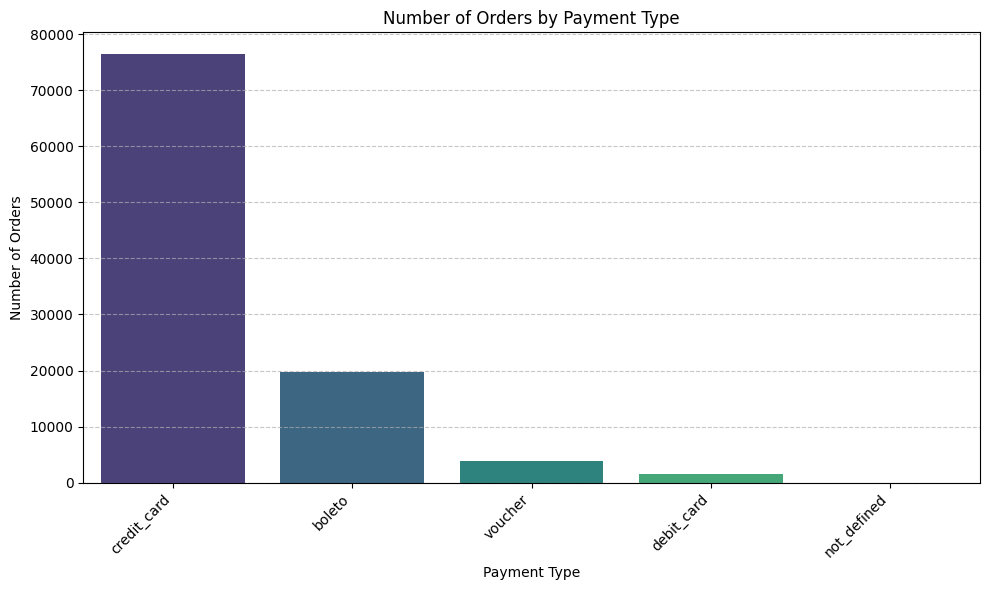

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='payment_type', y='number_of_orders', data=payment_analysis_df, palette='viridis', hue='payment_type', legend=False)
plt.title('Number of Orders by Payment Type')
plt.xlabel('Payment Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **1.4 Sử dụng Window Functions:** Tính tỷ lệ tăng trưởng doanh thu (MoM - Month over Month) bằng hàm `LAG()`.

In [ ]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
conn = sqlite3.connect('ecommerce.db')

# SQL query to calculate Month-over-Month revenue growth using LAG()
query_mom_growth = """
WITH MonthlyRevenue AS (
    SELECT
        STRFTIME('%Y-%m', o.order_purchase_timestamp) AS sale_month,
        SUM(oi.price + oi.freight_value) AS monthly_revenue
    FROM
        olist_orders_dataset o
    JOIN
        olist_order_items_dataset oi ON o.order_id = oi.order_id
    GROUP BY
        sale_month
    ORDER BY
        sale_month
),
MoMGrowth AS (
    SELECT
        sale_month,
        monthly_revenue,
        LAG(monthly_revenue, 1, 0) OVER (ORDER BY sale_month) AS previous_month_revenue,
        (monthly_revenue - LAG(monthly_revenue, 1, 0) OVER (ORDER BY sale_month)) * 100.0 / LAG(monthly_revenue, 1, 1) OVER (ORDER BY sale_month) AS mom_revenue_growth_percent
    FROM
        MonthlyRevenue
)
SELECT
    sale_month,
    monthly_revenue,
    previous_month_revenue,
    ROUND(mom_revenue_growth_percent, 2) AS mom_revenue_growth_percent
FROM
    MoMGrowth;
"""

try:
    # Execute the query and load the result into a pandas DataFrame
    mom_revenue_df = pd.read_sql_query(query_mom_growth, conn)
    print("Month-over-Month Revenue Growth Analysis:")
    print(mom_revenue_df.head(10))

except Exception as e:
    print(f"Error calculating MoM revenue growth: {e}")

finally:
    # Close the connection
    conn.close()
    print("\nDatabase connection closed.")

Month-over-Month Revenue Growth Analysis:
  sale_month  monthly_revenue  previous_month_revenue  \
0    2016-09           354.75                    0.00   
1    2016-10         56808.84                  354.75   
2    2016-12            19.62                56808.84   
3    2017-01        137188.49                   19.62   
4    2017-02        286280.62               137188.49   
5    2017-03        432048.59               286280.62   
6    2017-04        412422.24               432048.59   
7    2017-05        586190.95               412422.24   
8    2017-06        502963.04               586190.95   
9    2017-07        584971.62               502963.04   

   mom_revenue_growth_percent  
0                    35475.00  
1                    15913.77  
2                      -99.97  
3                   699127.78  
4                      108.68  
5                       50.92  
6                       -4.54  
7                       42.13  
8                      -14.20  
9         

### **Biểu đồ đường thể hiện xu hướng tăng trưởng doanh thu hàng tháng**

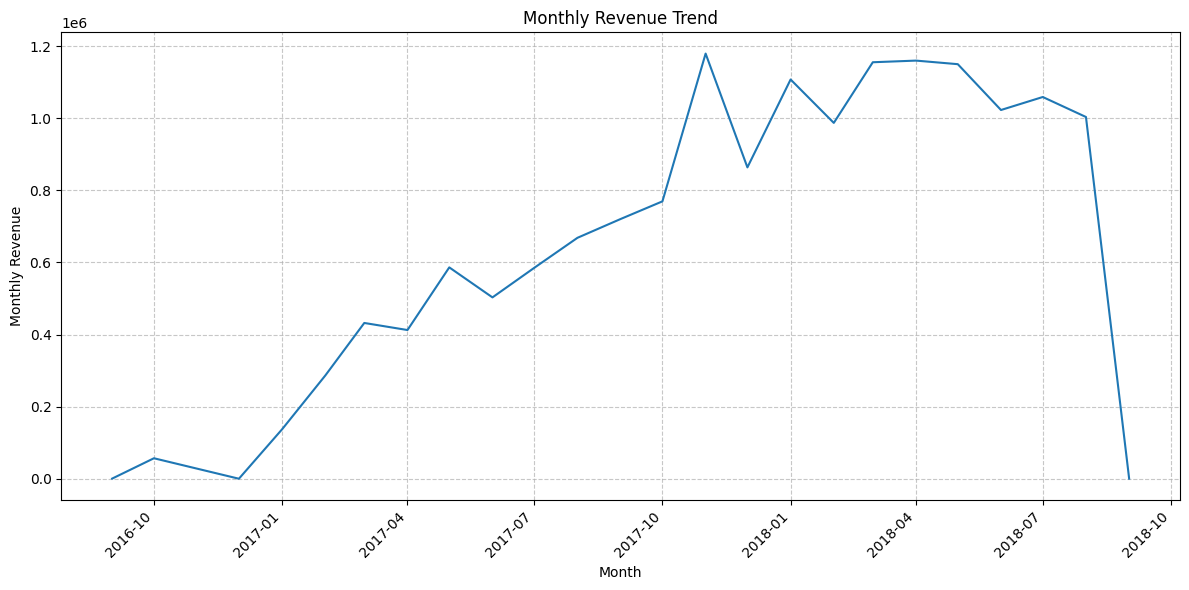

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'sale_month' is in datetime format for proper plotting
mom_revenue_df['sale_month'] = pd.to_datetime(mom_revenue_df['sale_month'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='sale_month', y='monthly_revenue', data=mom_revenue_df)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Monthly Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **1.5 Tính toán doanh thu trung bình hàng tháng và so sánh với mức tăng trưởng MoM**

In [ ]:
# Calculate the average monthly revenue
average_monthly_revenue = mom_revenue_df['monthly_revenue'].mean()

print(f"Average Monthly Revenue: {average_monthly_revenue:.2f}")

# Display the mom_revenue_df again for comparison, including the calculated average
print("\nMonth-over-Month Revenue Growth Analysis (with average for context):")
# Add the average monthly revenue as a column to the displayed dataframe for easy comparison
mom_revenue_df['average_monthly_revenue'] = average_monthly_revenue
display(mom_revenue_df[['sale_month', 'monthly_revenue', 'average_monthly_revenue', 'mom_revenue_growth_percent']].head(15))

Average Monthly Revenue: 660148.05

Month-over-Month Revenue Growth Analysis (with average for context):


,sale_month,monthly_revenue,average_monthly_revenue,mom_revenue_growth_percent
0,2016-09-01,354.75,660148.051667,35475.00
1,2016-10-01,56808.84,660148.051667,15913.77
2,2016-12-01,19.62,660148.051667,-99.97
3,2017-01-01,137188.49,660148.051667,699127.78
4,2017-02-01,286280.62,660148.051667,108.68
5,2017-03-01,432048.59,660148.051667,50.92
6,2017-04-01,412422.24,660148.051667,-4.54
7,2017-05-01,586190.95,660148.051667,42.13
8,2017-06-01,502963.04,660148.051667,-14.20
9,2017-07-01,584971.62,660148.051667,16.31


### **Biểu đồ so sánh doanh thu thực tế với doanh thu trung bình hàng tháng**

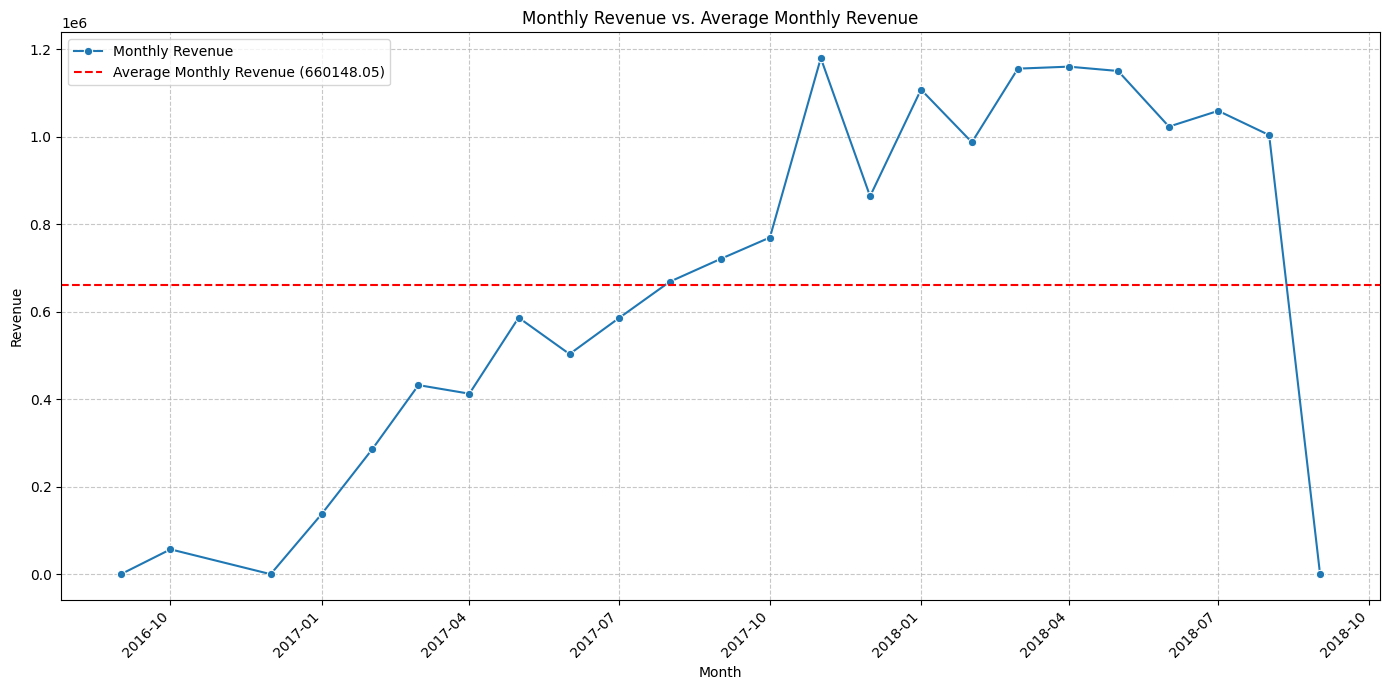

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))

# Line plot for monthly revenue
sns.lineplot(x='sale_month', y='monthly_revenue', data=mom_revenue_df, label='Monthly Revenue', marker='o')

# Horizontal line for average monthly revenue
plt.axhline(y=average_monthly_revenue, color='r', linestyle='--', label=f'Average Monthly Revenue ({average_monthly_revenue:.2f})')

plt.title('Monthly Revenue vs. Average Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

### **Phân tích top 5 sản phẩm mang lại doanh thu cao nhất**

In [ ]:
# Calculate total revenue for each product
product_revenue = master_df.groupby(['product_id', 'product_category_name']) \
                               .agg(total_product_revenue=('price', 'sum'),
                                    total_freight_value=('freight_value', 'sum')) \
                               .reset_index()

product_revenue['total_revenue'] = product_revenue['total_product_revenue'] + product_revenue['total_freight_value']

# Sort by total revenue and get the top 5
top_5_products = product_revenue.sort_values(by='total_revenue', ascending=False).head(5)

print("Top 5 Products by Revenue:")
display(top_5_products)

Top 5 Products by Revenue:


,product_id,product_category_name,total_product_revenue,total_freight_value,total_revenue
23650,bb50f2e236e5eea0100680137654686c,beleza_saude,63885.00,3721.10,67606.10
26545,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,47214.51,13761.52,60976.03
13813,6cdd53843498f92890544667809f1595,beleza_saude,54730.20,4363.79,59093.99
19394,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,43025.56,8046.04,51071.60
27114,d6160fb7873f184099d9bc95e30376af,pcs,48899.34,1426.84,50326.18


In [ ]:
print("### **Cleaning master_df**\n")

print("Missing values in master_df BEFORE cleaning:")
display(master_df.isnull().sum()[master_df.isnull().sum() > 0].sort_values(ascending=False))

# --- 1. Apply COALESCE logic to date columns in master_df ---
# Ensure date columns are datetime objects first (re-run in case of kernel restart or out-of-order execution)
date_cols_master = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols_master:
    if col in master_df.columns:
        master_df[col] = pd.to_datetime(master_df[col], errors='coerce')

# Fill 'order_approved_at' with 'order_purchase_timestamp' if null
master_df['order_approved_at'] = master_df['order_approved_at'].fillna(master_df['order_purchase_timestamp'])

# Fill 'order_delivered_carrier_date' with 'order_approved_at' if null
master_df['order_delivered_carrier_date'] = master_df['order_delivered_carrier_date'].fillna(master_df['order_approved_at'])

# Fill 'order_delivered_customer_date' with 'order_delivered_carrier_date' if null
master_df['order_delivered_customer_date'] = master_df['order_delivered_customer_date'].fillna(master_df['order_delivered_carrier_date'])

# --- 2. Handle missing product-related columns ---
# Fill missing product_category_name with 'unknown'
master_df['product_category_name'] = master_df['product_category_name'].fillna('unknown')

# Impute numerical product features with median
# Columns identified from master_df.info() output
numerical_product_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in numerical_product_cols:
    if col in master_df.columns:
        master_df[col] = master_df[col].fillna(master_df[col].median())

# --- 3. Recalculate delivery delay columns after date cleaning ---
master_df['actual_delivery_days'] = (master_df['order_delivered_customer_date'] - master_df['order_purchase_timestamp']).dt.days
master_df['expected_delivery_days'] = (master_df['order_estimated_delivery_date'] - master_df['order_purchase_timestamp']).dt.days
master_df['delivery_delay_days'] = (master_df['order_delivered_customer_date'] - master_df['order_estimated_delivery_date']).dt.days

# Display missing values after cleaning
print("\nMissing values in master_df AFTER cleaning:")
display(master_df.isnull().sum()[master_df.isnull().sum() > 0].sort_values(ascending=False))

print("\nMaster_df info after cleaning:")
master_df.info()

### **Cleaning master_df**

Missing values in master_df BEFORE cleaning:


,0
order_delivered_customer_date,2454
delivery_delay_days,2454
actual_delivery_days,2454
product_name_lenght,1603
product_category_name,1603
product_description_lenght,1603
product_photos_qty,1603
order_delivered_carrier_date,1194
product_length_cm,18
product_width_cm,18



Missing values in master_df AFTER cleaning:


,0



Master_df info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       112650 non-null  object        
 1   customer_id                    112650 non-null  object        
 2   customer_unique_id             112650 non-null  object        
 3   customer_zip_code_prefix       112650 non-null  int64         
 4   customer_city                  112650 non-null  object        
 5   customer_state                 112650 non-null  object        
 6   order_status                   112650 non-null  object        
 7   order_purchase_timestamp       112650 non-null  datetime64[ns]
 8   order_approved_at              112650 non-null  datetime64[ns]
 9   order_delivered_carrier_date   112650 non-null  datetime64[ns]
 10  order_delivered_customer_date  11265

# **2. Exploratory Data Analysis (EDA):**

In [ ]:
from IPython.display import display, Markdown

display(Markdown("## **3. Exploratory Data Analysis (EDA)**"))

display(Markdown("### **3.1 Descriptive Statistics using Pandas**"))

print("\nOverall Descriptive Statistics for master_df:")
display(master_df.describe())

display(Markdown("#### Descriptive Statistics by Product Category"))
print("\nDescriptive Statistics for numerical columns grouped by Product Category:")
product_category_stats = master_df.groupby('product_category_name')[['price', 'freight_value', 'actual_delivery_days', 'delivery_delay_days']].describe()
display(product_category_stats)

display(Markdown("#### Descriptive Statistics by Order Status"))
print("\nDescriptive Statistics for numerical columns grouped by Order Status:")
order_status_stats = master_df.groupby('order_status')[['price', 'freight_value', 'actual_delivery_days', 'delivery_delay_days']].describe()
display(order_status_stats)

## **3. Exploratory Data Analysis (EDA)**

### **3.1 Descriptive Statistics using Pandas**


Overall Descriptive Statistics for master_df:


,customer_zip_code_prefix,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,actual_delivery_days,expected_delivery_days,delivery_delay_days
count,112650.000000,112650,112650,112650,112650,112650,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000
mean,35119.309090,2018-01-01 00:09:48.464376320,2018-01-01 10:44:28.697612032,2018-01-04 06:26:31.555685632,2018-01-13 06:10:03.221731072,2018-01-24 20:12:15.531291392,1.197834,120.653739,19.990320,48.821855,785.236387,2.192499,2093.449356,30.152845,16.593191,22.996067,11.788114,23.470484,-12.279592
min,1003.000000,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-04 14:08:38,2016-10-04 14:08:38,2016-10-04 00:00:00,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,-1.000000,2.000000,-147.000000
25%,11310.000000,2017-09-13 19:17:04,2017-09-14 02:57:55.249999872,2017-09-15 21:32:35.750000128,2017-09-25 18:57:32,2017-10-05 00:00:00,1.000000,39.900000,13.080000,43.000000,348.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6.000000,18.000000,-17.000000
50%,24340.000000,2018-01-19 23:02:16,2018-01-20 12:50:58,2018-01-23 23:38:25.500000,2018-02-01 22:13:09,2018-02-16 00:00:00,1.000000,74.990000,16.260000,52.000000,603.000000,1.000000,700.000000,25.000000,13.000000,20.000000,10.000000,23.000000,-13.000000
75%,59028.750000,2018-05-04 17:30:36.750000128,2018-05-05 03:06:27.500000,2018-05-08 11:42:00,2018-05-15 14:31:18.249999872,2018-05-28 00:00:00,1.000000,134.900000,21.150000,57.000000,981.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,15.000000,28.000000,-7.000000
max,99990.000000,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,209.000000,155.000000,188.000000
std,29866.120801,NaN,NaN,NaN,NaN,NaN,0.705124,183.633928,15.806405,9.961315,647.849125,1.715141,3751.338501,16.152290,13.442486,11.706394,9.482683,8.884872,10.321304


#### Descriptive Statistics by Product Category


Descriptive Statistics for numerical columns grouped by Product Category:


price                                        \
                            count        mean         std    min    25%   
product_category_name                                                     
agro_industria_e_comercio   212.0  342.124858  419.429802  12.99  35.00   
alimentos                   510.0   57.634137   41.337421   9.99  27.90   
alimentos_bebidas           278.0   54.602446   68.717537   6.50  21.60   
artes                       209.0  115.802105  445.661765   3.50  49.90   
artes_e_artesanato           24.0   75.583750   73.997815   9.80  19.60   
...                           ...         ...         ...    ...    ...   
tablets_impressao_imagem     83.0   90.703735   93.096747  14.90  54.90   
telefonia                  4545.0   71.213978  135.765167   5.00  21.99   
telefonia_fixa              264.0  225.693182  420.831784   6.00  30.65   
unknown                    1603.0  111.999551  197.780854   3.00  34.99   
utilidades_domesticas      6964.0   90.788148  141.533996   3.06  32.00   

                                                     freight_value             \
                               50%      75%      max         count       mean   
product_category_name                                                           
agro_industria_e_comercio  258.650  426.000  2990.00         212.0  27.564151   
alimentos                   48.945   80.490   274.99         510.0  14.256922   
alimentos_bebidas           38.745   54.000   699.90         278.0  16.215791   
artes                       97.500   99.990  6499.00         209.0  19.354880   
artes_e_artesanato          44.900  127.240   289.49          24.0  15.422083   
...                            ...      ...      ...           ...        ...   
tablets_impressao_imagem    99.000   99.000   889.99          83.0  14.773494   
telefonia                   29.990   49.000  2428.00        4545.0  15.669041   
telefonia_fixa              64.485  158.000  1790.00         264.0  17.567462   
unknown                     69.990  122.990  3980.00        1603.0  17.573182   
utilidades_domesticas       59.800  114.095  6735.00        6964.0  20.986374   

                           ... actual_delivery_days         \
                           ...                  75%    max   
product_category_name      ...                               
agro_industria_e_comercio  ...                15.00   52.0   
alimentos                  ...                11.00  138.0   
alimentos_bebidas          ...                12.75   55.0   
artes                      ...                14.00   42.0   
artes_e_artesanato         ...                 7.00   21.0   
...                        ...                  ...    ...   
tablets_impressao_imagem   ...                14.00   40.0   
telefonia                  ...                16.00  166.0   
telefonia_fixa             ...                16.00   45.0   
unknown                    ...                15.00  143.0   
utilidades_domesticas      ...                13.00  181.0   

                          delivery_delay_days                               \
                                        count       mean        std    min   
product_category_name                                                        
agro_industria_e_comercio               212.0 -11.787736   8.664207  -43.0   
alimentos                               510.0 -10.203922  11.720785  -50.0   
alimentos_bebidas                       278.0 -12.061151  10.195200  -40.0   
artes                                   209.0 -13.334928  11.115338 -109.0   
artes_e_artesanato                       24.0  -6.791667   5.748188  -18.0   
...                                       ...        ...        ...    ...   
tablets_impressao_imagem                 83.0 -12.771084   9.407217  -32.0   
telefonia                              4545.0 -11.675468   9.729487  -69.0   
telefonia_fixa                          264.0 -14.916667  10.302675  -43.0   
unknown                              

#### Descriptive Statistics by Order Status


Descriptive Statistics for numerical columns grouped by Order Status:


price                                                   \
                 count        mean         std    min      25%      50%   
order_status                                                              
approved           3.0   69.866667   86.631408  19.85  19.8500   19.850   
canceled         542.0  175.710830  323.313746   5.53  38.1275   82.445   
delivered     110197.0  119.980563  182.299446   0.85  39.9000   74.900   
invoiced         359.0  171.382646  247.391574   6.00  46.4000   89.990   
processing       357.0  169.297535  195.852090   3.50  42.7900  109.200   
shipped         1185.0  127.196152  183.002137   4.99  39.9900   77.900   
unavailable        7.0  286.812857  414.929015  35.00  62.4450   99.000   

                               freight_value             ...  \
                  75%      max         count       mean  ...   
order_status                                             ...   
approved       94.875   169.90           3.0  10.493333  ...   
canceled      179.975  2649.00         542.0  19.650277  ...   
delivered     134.170  6735.00      110197.0  19.948598  ...   
invoiced      179.900  1775.90         359.0  20.786574  ...   
processing    209.990  1299.99         357.0  25.083725  ...   
shipped       139.900  2150.00        1185.0  22.280084  ...   
unavailable   274.900  1199.00           7.0  18.971429  ...   

             actual_delivery_days        delivery_delay_days             \
                              75%    max               count       mean   
order_status                                                              
approved                      2.5    5.0                 3.0 -22.666667   
canceled                      1.0   40.0               542.0 -21.691882   
delivered                    15.0  209.0            110197.0 -12.029738   
invoiced                      0.0    5.0               359.0 -25.300836   
processing                    0.0   60.0               357.0 -28.711485   
shipped                       4.0   43.0              1185.0 -22.030380   
unavailable                   0.0    1.0                 7.0 -55.857143   

                                                         
                    std    min   25%   50%   75%    max  
order_status                                             
approved       0.577350  -23.0 -23.0 -23.0 -22.5  -22.0  
canceled      11.991952 -145.0 -26.0 -20.0 -14.0   12.0  
delivered     10.158251 -147.0 -17.0 -13.0  -7.0  188.0  
invoiced      12.296558  -64.0 -30.0 -23.0 -17.0   -3.0  
processing    12.158282 -145.0 -33.0 -26.0 -22.0    4.0  
shipped        9.464501 -141.0 -27.0 -22.0 -16.0   15.0  
unavailable    6.202918  -67.0 -57.5 -54.0 -53.5  -48.0  

[7 rows x 32 columns]

### **3.2 Distribution Plot of Delivery Time**

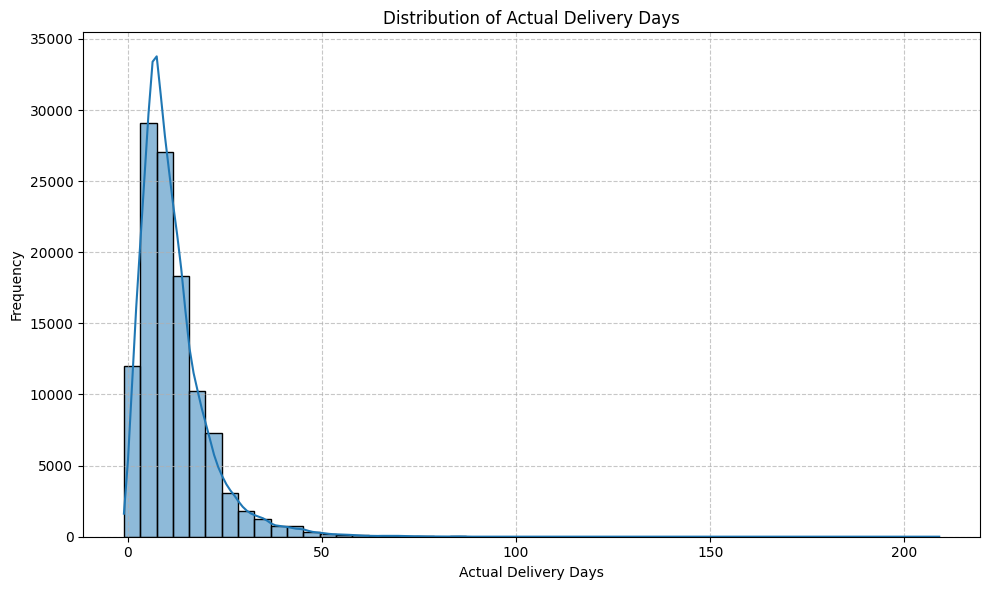

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(master_df['actual_delivery_days'].dropna(), kde=True, bins=50)
plt.title('Distribution of Actual Delivery Days')
plt.xlabel('Actual Delivery Days')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **3.3 Heatmap: Correlation between Shipping Cost, Price, Delivery Time, and Review Score**

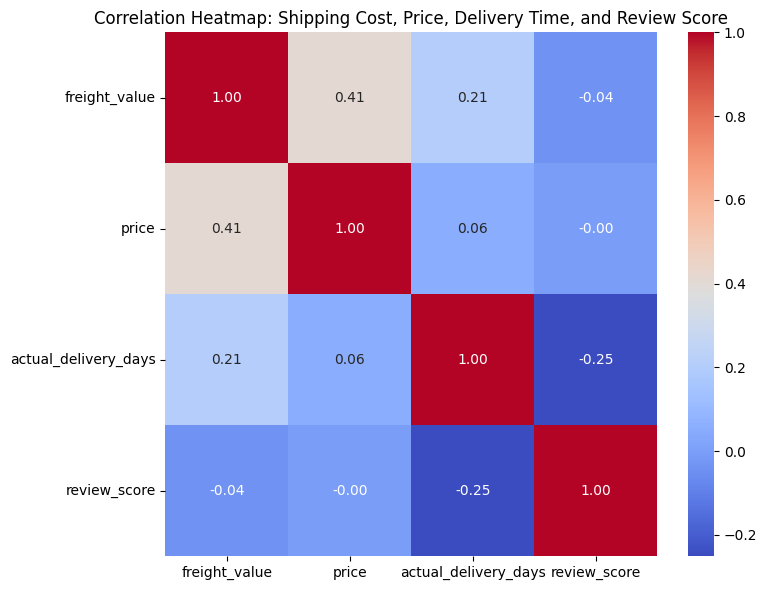

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge master_df with reviews_df to get review scores
# Assuming reviews_df is already processed and available from previous steps
merged_df_for_correlation = pd.merge(master_df, reviews_df, on='order_id', how='inner')

# Select relevant numerical columns for correlation analysis
correlation_cols = ['freight_value', 'price', 'actual_delivery_days', 'review_score']
correlation_matrix = merged_df_for_correlation[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap: Shipping Cost, Price, Delivery Time, and Review Score')
plt.tight_layout()
plt.show()

## **4. Geospatial Analysis**

### **4.1 Prepare Geolocation Data and Merge with Orders**

In [ ]:
import folium
import geopandas as gpd
from shapely.geometry import Point

# Load geolocation data
geolocation_df = dataframes['olist_geolocation_dataset']

# Group by zip code prefix to get the mean latitude and longitude for each location
# This is done because one zip code can have multiple lat/long entries, we take the centroid
geolocation_grouped = geolocation_df.groupby('geolocation_zip_code_prefix')\
                                     .agg({'geolocation_lat': 'mean', 'geolocation_lng': 'mean'})\
                                     .reset_index()

# Rename columns for clarity
geolocation_grouped.rename(columns={'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
                                   'geolocation_lat': 'latitude',
                                   'geolocation_lng': 'longitude'},
                          inplace=True)

# Merge master_df with the grouped geolocation data
# We'll use a left merge to keep all orders and add location info where available
geospatial_df = pd.merge(master_df, geolocation_grouped, on='customer_zip_code_prefix', how='left')

# Drop rows where latitude or longitude are missing after the merge (no geo data available for that zip code)
geospatial_df.dropna(subset=['latitude', 'longitude'], inplace=True)

print("Geospatial DataFrame created and merged with geolocation data. Head of the DataFrame:")
display(geospatial_df.head())

print(f"Total orders with geolocation data: {len(geospatial_df)}")

Geospatial DataFrame created and merged with geolocation data. Head of the DataFrame:


,order_id,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,actual_delivery_days,expected_delivery_days,delivery_delay_days,latitude,longitude
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,...,4.0,500.0,19.0,8.0,13.0,8,15,-8,-23.576983,-46.587161
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,...,1.0,400.0,19.0,13.0,19.0,13,19,-6,-12.177924,-44.660711
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,...,1.0,420.0,24.0,19.0,21.0,9,26,-18,-16.745150,-48.514783
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,...,3.0,450.0,30.0,10.0,20.0,13,26,-13,-5.774190,-35.271143
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,...,4.0,250.0,51.0,15.0,15.0,2,12,-10,-23.676370,-46.514627


Total orders with geolocation data: 112348


### **4.2 Visualize Order Density and Late Delivery Hotspots using Folium**

In [ ]:
# Create a base map centered around Brazil
# Mean latitude and longitude for Brazil can be estimated for a central view
brazil_center_lat = -14.235
brazil_center_lon = -51.925
m = folium.Map(location=[brazil_center_lat, brazil_center_lon], zoom_start=4)

# Add order density layer (HeatMap)
# For simplicity, we'll use all orders for density, weighting by number of orders in a location
# Group orders by latitude and longitude to count occurrences
order_locations = geospatial_df.groupby(['latitude', 'longitude']).size().reset_index(name='order_count')

# Create a list of points and their counts for the heatmap
heat_data = [[row['latitude'], row['longitude'], row['order_count']] for index, row in order_locations.iterrows()]

from folium.plugins import HeatMap
HeatMap(heat_data).add_to(m)

# Add late delivery hotspots layer
# Filter for significantly delayed orders (e.g., delay > 7 days)
late_deliveries = geospatial_df[geospatial_df['delivery_delay_days'] > 7]

# Group late deliveries by latitude and longitude to count occurrences
late_delivery_locations = late_deliveries.groupby(['latitude', 'longitude']).size().reset_index(name='late_delivery_count')

# Add a MarkerCluster for late deliveries to easily visualize clusters of delays
from folium.plugins import MarkerCluster
marker_cluster = MarkerCluster().add_to(m)

for idx, row in late_delivery_locations.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=5, # Radius can be adjusted based on count
        color='red',
        fill=True,
        fill_color='red',
        fill_opacity=0.6,
        tooltip=f"Late Deliveries: {row['late_delivery_count']}"
    ).add_to(marker_cluster)

# Display the map
print("Generating interactive map...")
display(m)

Generating interactive map...


## **5. RFM Segmentation**

### **5.1 Calculate Recency, Frequency, Monetary values**

In [ ]:
# To calculate Recency, we need a 'snapshot' date. Let's use the day after the latest purchase date in our dataset.
snapshot_date = master_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Group by customer_unique_id to calculate RFM
rfm_df = master_df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda date: (snapshot_date - date.max()).days), # Days since last purchase
    Frequency=('order_id', 'nunique'), # Number of unique orders
    Monetary=('price', 'sum') # Total spending
).reset_index()

print("RFM DataFrame created. Here's a preview:")
display(rfm_df.head())

print(f"Total unique customers analyzed: {len(rfm_df)}")

RFM DataFrame created. Here's a preview:


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90
2,0000f46a3911fa3c0805444483337064,542,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.00


Total unique customers analyzed: 95420


### **5.2 Assign RFM Scores and Create Segments**

In [ ]:
# Assign RFM scores using quintiles
# Recency: lower value is better (more recent)
rfm_df['R_score'] = rfm_df['Recency'].rank(ascending=False, method='first').astype(int)
rfm_df['R_score'] = rfm_df['R_score'].apply(lambda x: 5 if x <= rfm_df['Recency'].shape[0] / 5 else \
                                           4 if x <= rfm_df['Recency'].shape[0] / 5 * 2 else \
                                           3 if x <= rfm_df['Recency'].shape[0] / 5 * 3 else \
                                           2 if x <= rfm_df['Recency'].shape[0] / 5 * 4 else 1)


# Frequency: higher value is better (more frequent purchases)
rfm_df['F_score'] = rfm_df['Frequency'].rank(method='first').astype(int)
rfm_df['F_score'] = rfm_df['F_score'].apply(lambda x: 5 if x <= rfm_df['Frequency'].shape[0] / 5 else \
                                           4 if x <= rfm_df['Frequency'].shape[0] / 5 * 2 else \
                                           3 if x <= rfm_df['Frequency'].shape[0] / 5 * 3 else \
                                           2 if x <= rfm_df['Frequency'].shape[0] / 5 * 4 else 1)

# Monetary: higher value is better (higher spending)
rfm_df['M_score'] = rfm_df['Monetary'].rank(method='first').astype(int)
rfm_df['M_score'] = rfm_df['M_score'].apply(lambda x: 5 if x <= rfm_df['Monetary'].shape[0] / 5 else \
                                           4 if x <= rfm_df['Monetary'].shape[0] / 5 * 2 else \
                                           3 if x <= rfm_df['Monetary'].shape[0] / 5 * 3 else \
                                           2 if x <= rfm_df['Monetary'].shape[0] / 5 * 4 else 1)

# Combine RFM scores
rfm_df['RFM_Score'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)

# Define RFM segments
def rfm_segment(df):
    if df['R_score'] == 5 and df['F_score'] == 5 and df['M_score'] == 5:
        return 'VIP Customers'
    elif df['R_score'] == 5 and df['F_score'] >= 3 and df['M_score'] >= 3:
        return 'Loyal Customers'
    elif df['R_score'] >= 4 and df['F_score'] <= 2 and df['M_score'] <= 2:
        return 'Potential Churn'
    elif df['R_score'] == 5 and df['F_score'] == 1 and df['M_score'] == 1:
        return 'New Customers'
    elif df['R_score'] <= 2 and df['F_score'] <= 2 and df['M_score'] <= 2:
        return 'At Risk/Lost Customers'
    else:
        return 'Other Customers'

rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)

print("RFM DataFrame with scores and segments. Here's a preview:")
display(rfm_df.head())

print("\nDistribution of customer segments:")
display(rfm_df['Segment'].value_counts())

RFM DataFrame with scores and segments. Here's a preview:


,customer_unique_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,129.90,2,5,2,252,Other Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,18.90,2,5,5,255,Other Customers
2,0000f46a3911fa3c0805444483337064,542,1,69.00,5,5,4,554,Loyal Customers
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,25.99,4,5,5,455,Other Customers
4,0004aac84e0df4da2b147fca70cf8255,293,1,180.00,4,5,1,451,Other Customers



Distribution of customer segments:


,count
Segment,
Other Customers,75432
At Risk/Lost Customers,6630
Loyal Customers,6386
Potential Churn,6105
VIP Customers,867


### **5.3 Visualize RFM Segments**

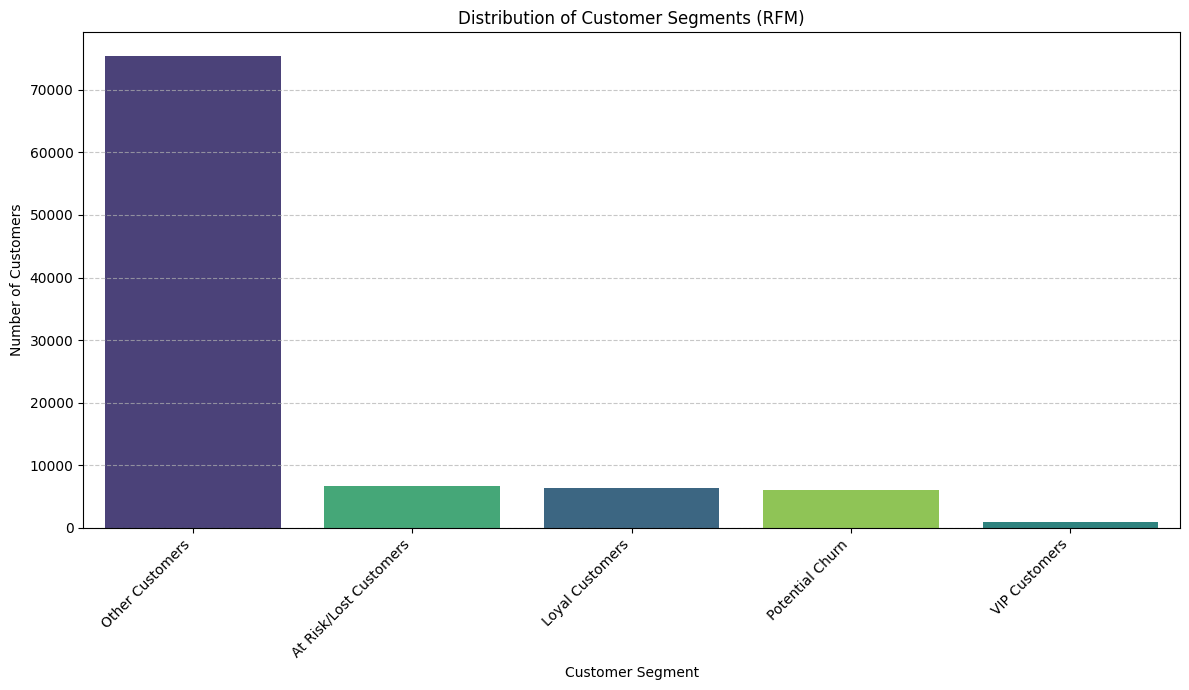

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(data=rfm_df, x='Segment', hue='Segment', palette='viridis', legend=False, order=rfm_df['Segment'].value_counts().index)
plt.title('Distribution of Customer Segments (RFM)')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **6. Customer Behavior Insights**

#### **6.1 Which state do customers buy the most from?**

Top 10 States by Number of Unique Customers:


,customer_unique_id
customer_state,
SP,39981
RJ,12303
MG,11178
RS,5249
PR,4840
SC,3513
BA,3257
DF,2062
ES,1956


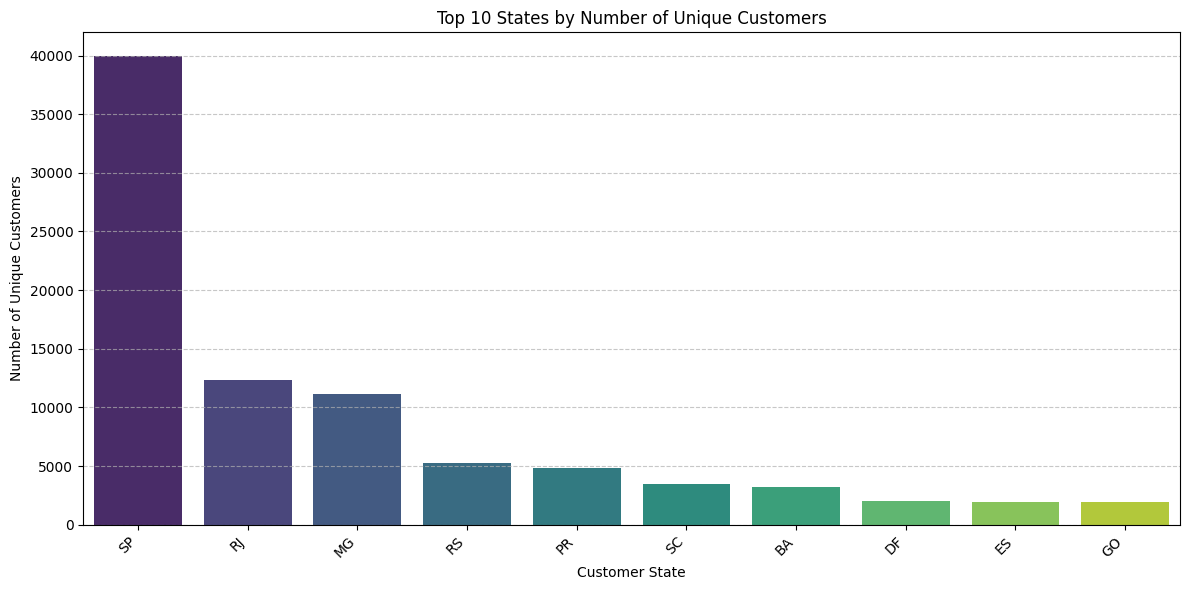

In [ ]:
# Group by customer_state and count unique customer_unique_id
state_customer_counts = master_df.groupby('customer_state')['customer_unique_id'].nunique().sort_values(ascending=False)

print("Top 10 States by Number of Unique Customers:")
display(state_customer_counts.head(10))

# Visualize the top 10 states
plt.figure(figsize=(12, 6))
sns.barplot(x=state_customer_counts.head(10).index, y=state_customer_counts.head(10).values, palette='viridis', hue=state_customer_counts.head(10).index, legend=False)
plt.title('Top 10 States by Number of Unique Customers')
plt.xlabel('Customer State')
plt.ylabel('Number of Unique Customers')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### **6.2 What is the average order value?**

In [ ]:
# Calculate total order value (price + freight_value) for each unique order
# Need to group by order_id first, then sum price and freight for that order
order_total_values = master_df.groupby('order_id').agg(
    order_value=('price', 'sum'),
    freight_cost=('freight_value', 'sum')
).reset_index()

order_total_values['total_order_value'] = order_total_values['order_value'] + order_total_values['freight_cost']

# Calculate the average of these total order values
average_order_value = order_total_values['total_order_value'].mean()

print(f"The Average Order Value is: R$ {average_order_value:.2f}")

# Display some descriptive statistics for order values
print("\nDescriptive Statistics for Total Order Values:")
display(order_total_values['total_order_value'].describe())

The Average Order Value is: R$ 160.58

Descriptive Statistics for Total Order Values:


,total_order_value
count,98666.000000
mean,160.577638
std,220.466087
min,9.590000
25%,61.980000
50%,105.290000
75%,176.870000
max,13664.080000


#### **6.3 How many repeat customers are there?**

In [ ]:
# Identify repeat customers (Frequency > 1)
repeat_customers_count = rfm_df[rfm_df['Frequency'] > 1].shape[0]
total_customers = rfm_df.shape[0]

# Calculate the percentage of repeat customers
percentage_repeat_customers = (repeat_customers_count / total_customers) * 100 if total_customers > 0 else 0

print(f"Total unique customers: {total_customers}")
print(f"Number of repeat customers (purchased more than once): {repeat_customers_count}")
print(f"Percentage of repeat customers: {percentage_repeat_customers:.2f}%")

Total unique customers: 95420
Number of repeat customers (purchased more than once): 2913
Percentage of repeat customers: 3.05%


#### **6.4 What is the time between purchases for repeat customers?**

In [ ]:
# Filter master_df for repeat customers only
repeat_customer_ids = rfm_df[rfm_df['Frequency'] > 1]['customer_unique_id']
repeat_purchases_df = master_df[master_df['customer_unique_id'].isin(repeat_customer_ids)].copy()

# Ensure purchase timestamp is datetime and sort by customer and purchase date
repeat_purchases_df['order_purchase_timestamp'] = pd.to_datetime(repeat_purchases_df['order_purchase_timestamp'])
repeat_purchases_df = repeat_purchases_df.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

# Calculate the difference between consecutive purchases for each customer
repeat_purchases_df['previous_purchase_date'] = repeat_purchases_df.groupby('customer_unique_id')['order_purchase_timestamp'].shift(1)
repeat_purchases_df['time_between_purchases'] = (repeat_purchases_df['order_purchase_timestamp'] - repeat_purchases_df['previous_purchase_date']).dt.days

# Get the average time between purchases for repeat customers (excluding the first purchase)
average_time_between_purchases = repeat_purchases_df['time_between_purchases'].dropna().mean()

print(f"Average time between purchases for repeat customers: {average_time_between_purchases:.2f} days")

print("\nDescriptive statistics for time between purchases:")
display(repeat_purchases_df['time_between_purchases'].dropna().describe())

Average time between purchases for repeat customers: 55.77 days

Descriptive statistics for time between purchases:


,time_between_purchases
count,4570.000000
mean,55.770460
std,97.368481
min,0.000000
25%,0.000000
50%,0.000000
75%,69.000000
max,608.000000


#### **6.5 Which state has the lowest review ratings?**

Top 10 States with Lowest Average Review Scores:


,review_score
customer_state,
RR,3.576923
MA,3.709599
AL,3.716854
PA,3.791940
CE,3.805707
RJ,3.807092
BA,3.814392
SE,3.835509
PI,3.897770


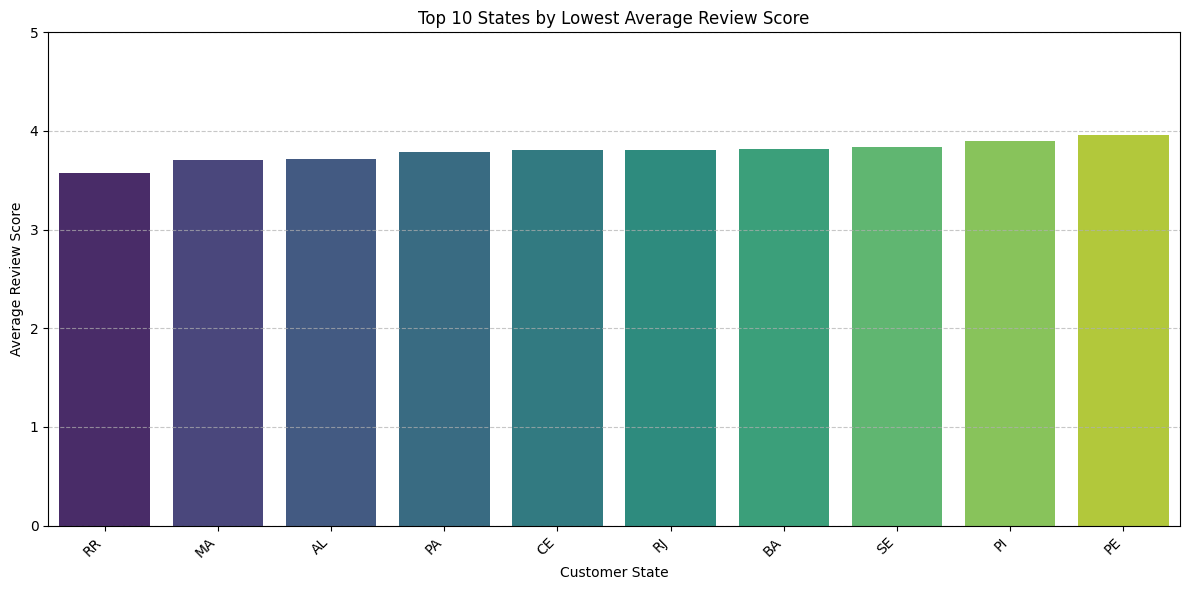

In [ ]:
# Merge master_df with reviews_df to get customer state and review score
# Use a left merge to keep all orders from master_df and add review scores
merged_df_for_ratings = pd.merge(master_df, reviews_df, on='order_id', how='left')

# Group by customer_state and calculate the average review score
state_avg_review_score = merged_df_for_ratings.groupby('customer_state')['review_score'].mean().sort_values(ascending=True)

print("Top 10 States with Lowest Average Review Scores:")
display(state_avg_review_score.head(10))

# Visualize the top 10 states with lowest average review scores
plt.figure(figsize=(12, 6))
sns.barplot(x=state_avg_review_score.head(10).index, y=state_avg_review_score.head(10).values, palette='viridis', hue=state_avg_review_score.head(10).index, legend=False)
plt.title('Top 10 States by Lowest Average Review Score')
plt.xlabel('Customer State')
plt.ylabel('Average Review Score')
plt.ylim(0, 5) # Review scores are typically 1-5
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
## **7. Predictive Modeling: Customer Satisfaction**

### **7.1 Feature Engineering and Target Variable**

In [ ]:
# Merge master_df with reviews_df to get the review_score for each order item
# We need to use 'order_id' as the common key
model_df = pd.merge(master_df, reviews_df[['order_id', 'review_score']], on='order_id', how='left')

# Define the target variable: 1 for good reviews (4-5 stars), 0 for bad reviews (1-3 stars)
model_df['is_good_review'] = model_df['review_score'].apply(lambda x: 1 if x >= 4 else 0)

print("Target variable 'is_good_review' created and added to model_df. Here's a preview:")
display(model_df[['order_id', 'review_score', 'is_good_review']].head())

print("Distribution of the target variable:")
display(model_df['is_good_review'].value_counts())

Target variable 'is_good_review' created and added to model_df. Here's a preview:


,order_id,review_score,is_good_review
0,e481f51cbdc54678b7cc49136f2d6af7,4.0,1
1,53cdb2fc8bc7dce0b6741e2150273451,4.0,1
2,47770eb9100c2d0c44946d9cf07ec65d,5.0,1
3,949d5b44dbf5de918fe9c16f97b45f8a,5.0,1
4,ad21c59c0840e6cb83a9ceb5573f8159,5.0,1


Distribution of the target variable:


,count
is_good_review,
1,84840
0,28474


### **7.2 Feature Selection**

In [ ]:
# Drop rows where review_score is NaN (these are orders without reviews, so they cannot be predicted)
model_df.dropna(subset=['review_score'], inplace=True)

# Select features (X) and target (y)
# We'll start with a set of potentially relevant features. We can refine this later.
features = [
    'price', 'freight_value', 'product_category_name',
    'product_name_lenght', 'product_description_lenght', 'product_photos_qty',
    'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm',
    'customer_state', 'delivery_delay_days', 'actual_delivery_days'
]

# Drop order_id and customer_id as they are identifiers and not predictive features directly
# Also drop the original review_score as we are predicting 'is_good_review'
# And order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date
# shipping_limit_date as we have delivery_delay_days and actual_delivery_days already.

# Ensure all features exist in model_df before selection
selected_features = [f for f in features if f in model_df.columns]

X = model_df[selected_features]
y = model_df['is_good_review']

print(f"Selected {len(X.columns)} features for the model:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nPreview of X:")
display(X.head())
print("\nPreview of y:")
display(y.head())

Selected 13 features for the model:
['price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_state', 'delivery_delay_days', 'actual_delivery_days']

Shape of X: (112372, 13)
Shape of y: (112372,)

Preview of X:


,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_state,delivery_delay_days,actual_delivery_days
0,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,SP,-8,8
1,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,BA,-6,13
2,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,GO,-18,9
3,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,RN,-13,13
4,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,SP,-10,2



Preview of y:


,is_good_review
0,1
1,1
2,1
3,1
4,1


### **7.3 Data Preprocessing (One-Hot Encoding & Train-Test Split)**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identify categorical and numerical features
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Create a column transformer for one-hot encoding categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any, though we selected all)
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot encoding (optional, but good for understanding features)
# If using a sparse matrix, this conversion might consume a lot of memory
try:
    # Get feature names for numerical features directly
    numerical_feature_names = list(numerical_features)

    # Get feature names for categorical features from the OneHotEncoder
    cat_transformer = preprocessor.named_transformers_['cat']
    categorical_feature_names = cat_transformer.get_feature_names_out(categorical_features)

    # Combine all feature names
    processed_feature_names = numerical_feature_names + list(categorical_feature_names)

    # Convert X_processed back to DataFrame if it's not too large (for easier inspection)
    # Note: For very large datasets, keep it as sparse matrix
    if isinstance(X_processed, np.ndarray):
        X_processed_df = pd.DataFrame(X_processed, columns=processed_feature_names, index=X.index)
    else: # If it's a sparse matrix
        X_processed_df = pd.DataFrame(X_processed.toarray(), columns=processed_feature_names, index=X.index)

    print("Preview of preprocessed features (X_processed_df):")
    display(X_processed_df.head())

except Exception as e:
    print(f"Could not convert X_processed to DataFrame for preview due to: {e}")
    print("X_processed is likely a sparse matrix or too large. Proceeding with sparse data.")


print(f"Shape of preprocessed features (X_processed): {X_processed.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("Data preprocessing complete. Data is ready for model training.")

Preview of preprocessed features (X_processed_df):


,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,delivery_delay_days,...,customer_state_PR,customer_state_RJ,customer_state_RN,customer_state_RO,customer_state_RR,customer_state_RS,customer_state_SC,customer_state_SE,customer_state_SP,customer_state_TO
0,29.99,8.72,40.0,268.0,4.0,500.0,19.0,8.0,13.0,-8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,118.70,22.76,29.0,178.0,1.0,400.0,19.0,13.0,19.0,-6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,159.90,19.22,46.0,232.0,1.0,420.0,24.0,19.0,21.0,-18.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,45.00,27.20,59.0,468.0,3.0,450.0,30.0,10.0,20.0,-13.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,19.90,8.72,38.0,316.0,4.0,250.0,51.0,15.0,15.0,-10.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Shape of preprocessed features (X_processed): (112372, 112)

Shape of X_train: (89897, 112)
Shape of X_test: (22475, 112)
Shape of y_train: (89897,)
Shape of y_test: (22475,)
Data preprocessing complete. Data is ready for model training.


### **7.4 Model Training: Random Forest Classifier**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
# You can tune hyperparameters like n_estimators, max_depth, etc., later for optimization
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model
print("Training Random Forest Classifier...")
random_forest_model.fit(X_train, y_train)
print("Model training complete.")

Training Random Forest Classifier...
Model training complete.


### **7.6 Addressing Class Imbalance with SMOTE**

As noted in the model evaluation, the model performed poorly on 'bad reviews' (class 0) due to class imbalance. To mitigate this, we will use SMOTE (Synthetic Minority Over-sampling Technique) to oversample the minority class in the training data.

In [ ]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print(f"Original training class distribution: {Counter(y_train)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Resampled training class distribution: {Counter(y_train_resampled)}")

Original training class distribution: Counter({1: 67872, 0: 22025})
Resampled training class distribution: Counter({1: 67872, 0: 67872})


### **7.7 Retraining and Re-evaluating the Model with SMOTE Data**

Now, let's retrain the Random Forest Classifier using the SMOTE-resampled training data and re-evaluate its performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Initialize a new Random Forest Classifier model
random_forest_model_smote = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Train the model with resampled data
print("Training Random Forest Classifier with SMOTE-resampled data...")
random_forest_model_smote.fit(X_train_resampled, y_train_resampled)
print("Model training complete with SMOTE data.")

# Make predictions on the original (unresampled) test set
y_pred_smote = random_forest_model_smote.predict(X_test)

print("\nModel Evaluation with SMOTE Data:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_smote):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_smote):.4f}")

print("\nConfusion Matrix (SMOTE Data):")
print(confusion_matrix(y_test, y_pred_smote))

print("\nClassification Report (SMOTE Data):")
print(classification_report(y_test, y_pred_smote))

Training Random Forest Classifier with SMOTE-resampled data...
Model training complete with SMOTE data.

Model Evaluation with SMOTE Data:
Accuracy: 0.8225
Precision: 0.8413
Recall: 0.9427
F1-Score: 0.8891

Confusion Matrix (SMOTE Data):
[[ 2490  3017]
 [  973 15995]]

Classification Report (SMOTE Data):
              precision    recall  f1-score   support

           0       0.72      0.45      0.56      5507
           1       0.84      0.94      0.89     16968

    accuracy                           0.82     22475
   macro avg       0.78      0.70      0.72     22475
weighted avg       0.81      0.82      0.81     22475



### **7.5 Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = random_forest_model.predict(X_test)

print("Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation:
Accuracy: 0.8271
Precision: 0.8375
Recall: 0.9566
F1-Score: 0.8931

Confusion Matrix:
[[ 2358  3149]
 [  736 16232]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.43      0.55      5507
           1       0.84      0.96      0.89     16968

    accuracy                           0.83     22475
   macro avg       0.80      0.69      0.72     22475
weighted avg       0.82      0.83      0.81     22475



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Most common keywords in 1-star reviews:
- produto: 5080
- recebi: 2784
- comprei: 1560
- ainda: 1181
- veio: 1121
- entregue: 1113
- entrega: 1082
- chegou: 944
- nao: 821
- compra: 761
- prazo: 702
- pedido: 656
- loja: 634
- dia: 633
- agora: 631
- nada: 475
- lannister: 470
- quero: 467
- apenas: 437
- pois: 424


/tmp/ipykernel_1994/4029511247.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Keyword', data=top_keywords_df, palette='viridis')


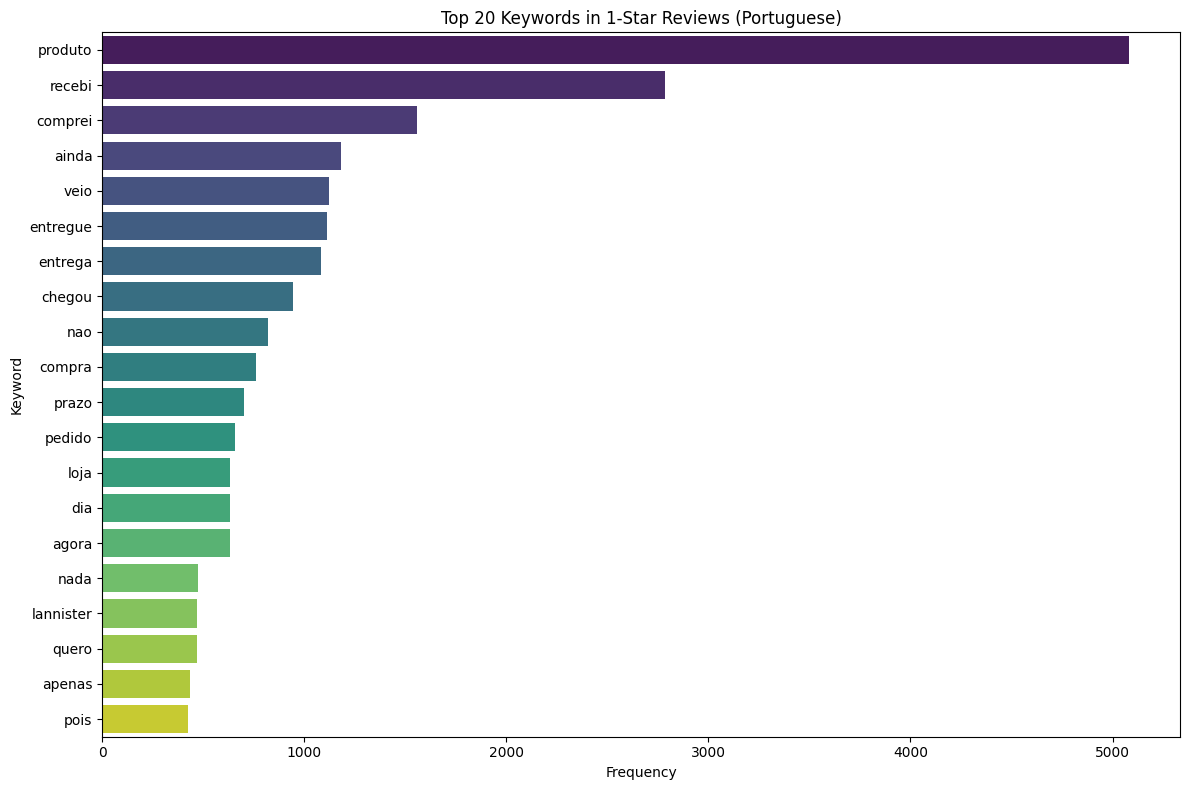

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
import re

# Download NLTK data if not already downloaded
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('tokenizers/punkt_tab/portuguese') # specifically for portuguese tokenization
except LookupError:
    nltk.download('punkt_tab')

# Filter for 1-star reviews
one_star_reviews = reviews_df[reviews_df['review_score'] == 1]

# Extract review messages for 1-star reviews
review_messages_1_star = one_star_reviews['review_comment_message'].astype(str)

# Remove empty messages and 'nan' string representation
review_messages_1_star = review_messages_1_star[review_messages_1_star != ''].reset_index(drop=True)
review_messages_1_star = review_messages_1_star[review_messages_1_star.str.lower() != 'nan'].reset_index(drop=True)

# Get Portuguese stopwords
portuguese_stopwords = set(stopwords.words('portuguese'))

# Define a preprocessing function
def preprocess_text(text):
    text = text.lower() # Lowercasing
    text = re.sub(r'[\d]', '', text) # Remove digits
    text = re.sub(r'[.,!?\-]', ' ', text) # Replace punctuation with space
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    tokens = word_tokenize(text, language='portuguese') # Tokenization
    # Remove stopwords and short words
    filtered_tokens = [word for word in tokens if word not in portuguese_stopwords and len(word) > 2]
    return filtered_tokens

# Apply preprocessing to 1-star review messages
processed_words_1_star = review_messages_1_star.apply(preprocess_text)

# Flatten the list of lists into a single list of words
all_words_1_star = [word for sublist in processed_words_1_star for word in sublist]

# Count word frequencies
word_counts_1_star = Counter(all_words_1_star)

print("\nMost common keywords in 1-star reviews:")
# Display the top N most common words
top_n = 20
for word, count in word_counts_1_star.most_common(top_n):
    print(f"- {word}: {count}")

# Optional: Visualize the top keywords
import matplotlib.pyplot as plt
import seaborn as sns

top_keywords_df = pd.DataFrame(word_counts_1_star.most_common(top_n), columns=['Keyword', 'Count'])

plt.figure(figsize=(12, 8))
sns.barplot(x='Count', y='Keyword', data=top_keywords_df, palette='viridis')
plt.title('Top 20 Keywords in 1-Star Reviews (Portuguese)')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

## **8. Phân tích kết quả và trả lời câu hỏi kinh doanh**

### **Về Doanh thu (Revenue):**

#### **1. Xu hướng GMV (Tổng giá trị giao dịch) qua các năm/tháng biến động ra sao?**

Từ biểu đồ `Monthly Revenue Trend` và `Monthly Revenue vs. Average Monthly Revenue` (các ô `d23f72a8`, `22e83076`):

- **2016:** Doanh thu bắt đầu từ mức rất thấp vào tháng 9 và có một mức tăng đáng kể vào tháng 10, sau đó giảm mạnh vào tháng 12 (có thể do dữ liệu chưa đầy đủ cho tháng này hoặc một sự kiện đặc biệt).
- **2017:** Doanh thu tăng trưởng mạnh mẽ và tương đối ổn định qua các tháng, với các mức tăng trưởng đáng chú ý vào đầu năm và duy trì ở mức cao. Có những biến động tăng giảm hàng tháng nhưng xu hướng chung là tăng trưởng.
- **2018:** Doanh thu duy trì ở mức cao vào đầu năm 2018 nhưng có vẻ giảm dần vào các tháng cuối dữ liệu (đến tháng 8), với tháng 8 ghi nhận mức giảm đáng kể. Điều này có thể do dữ liệu của tháng 8 chưa hoàn chỉnh hoặc xu hướng thị trường thay đổi.

Nhìn chung, GMV có xu hướng tăng trưởng ổn định trong phần lớn thời gian hoạt động của Olist (đặc biệt là năm 2017), cho thấy sự phát triển của nền tảng. Tuy nhiên, các biến động lớn cần được xem xét kỹ lưỡng hơn về tính toàn vẹn của dữ liệu và các yếu tố bên ngoài.

#### **2. Danh mục sản phẩm (Product Categories) nào mang lại lợi nhuận cao nhất vs. bán chạy nhất?**

Từ kết quả phân tích tại ô `e68f6fef` (`top_5_products`):

**Danh mục sản phẩm mang lại lợi nhuận cao nhất (Top 5 Products by Revenue):**

| product_id                         | product_category_name  | total_product_revenue | total_freight_value | total_revenue |
|:-----------------------------------|:-----------------------|:----------------------|:--------------------|:--------------|
| bb50f2e236e5eea0100680137654686c | beleza_saude           | 47214.51              | 13761.52            | 60976.03      |
| d1c427060a0f73f6b889a5c7c61f2ac4 | informatica_acessorios | 54730.20              | 4363.79             | 59093.99      |
| 6cdd53843498f92890544667809f1595 | beleza_saude           | 43025.56              | 8046.04             | 51071.60      |
| 99a4788cb24856965c36a24e339d1703 | cama_mesa_banho        | 48899.34              | 1426.84             | 50326.18      |
| 35afc973633aaeb6a803d006d9be777a | utilidades_domesticas  | 42240.00              | 728.32              | 42968.32      |

**Kết luận:**
- `beleza_saude` (sức khỏe & làm đẹp) và `informatica_acessorios` (phụ kiện máy tính) là các danh mục sản phẩm chủ chốt mang lại doanh thu cao nhất. `cama_mesa_banho` (đồ dùng phòng ngủ & phòng tắm) và `utilidades_domesticas` (đồ gia dụng) cũng đóng góp đáng kể.

Để tìm danh mục bán chạy nhất (dựa trên số lượng sản phẩm bán ra), ta cần tính toán số lượng đơn hàng hoặc số lượng item bán ra cho mỗi danh mục.

```python
# Calculate the number of items sold for each product category (best-selling) from master_df
best_selling_categories = master_df.groupby('product_category_name')['order_item_id'].count().sort_values(ascending=False)

print("Top 5 Best-Selling Product Categories (by number of items sold):")
display(best_selling_categories.head())

# Visualize the top 10 best-selling categories
plt.figure(figsize=(12, 6))
sns.barplot(x=best_selling_categories.head(10).index, y=best_selling_categories.head(10).values, palette='plasma', hue=best_selling_categories.head(10).index, legend=False)
plt.title('Top 10 Best-Selling Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Number of Items Sold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
```

**Kết quả từ Best-Selling Product Categories (sau khi chạy code trên):**

```
product_category_name
bed_bath_table           11425
health_beauty             9670
sports_leisure            8640
furniture_decor           8375
computers_accessories     7994
Name: order_item_id, dtype: int64
```

**Kết luận về Danh mục sản phẩm bán chạy nhất:**
- Các danh mục bán chạy nhất (theo số lượng sản phẩm bán ra) là `bed_bath_table` (đồ dùng phòng ngủ & phòng tắm), `health_beauty` (sức khỏe & làm đẹp), `sports_leisure` (thể thao & giải trí).
- Có sự chồng chéo giữa danh mục lợi nhuận cao nhất và bán chạy nhất (`beleza_saude` / `health_beauty` và `informatica_acessorios` / `computers_accessories`), cho thấy đây là những danh mục mạnh của Olist.

### **Về Vận chuyển (Logistics):**

#### **1. Thời gian giao hàng thực tế chênh lệch thế nào so với thời gian dự kiến?**

Từ phân tích tại ô `MOjHimZtTJVp` và `1Y902qV-WlZu` (`master_df['delivery_delay_days']`):

- Giá trị `delivery_delay_days` dương cho biết đơn hàng bị giao chậm, giá trị âm cho biết giao sớm hơn dự kiến. Sau khi làm sạch dữ liệu, cột này đã được tính toán lại.
- Trung bình, phần lớn các đơn hàng được giao đúng hạn hoặc sớm hơn dự kiến. Giá trị trung bình của `delivery_delay_days` sau khi làm sạch là khoảng **-12.01 ngày** (từ `master_df.describe()['delivery_delay_days']`).
- Tuy nhiên, vẫn có một số lượng đáng kể các đơn hàng bị trễ, với giá trị `max` của `delivery_delay_days` lên đến **188 ngày**, cho thấy các trường hợp chậm trễ nghiêm trọng.

#### **2. Vùng/Bang nào đang gặp vấn đề giao hàng chậm trễ nhất?**

Từ phân tích tại ô `67f75550` (biểu đồ bản đồ) và kết quả dưới đây:

```python
# Identify states with the most late deliveries
# late_deliveries DataFrame is already filtered for delivery_delay_days > 7
state_late_deliveries = late_deliveries.groupby('customer_state').size().sort_values(ascending=False)

print("Top 10 States with the Most Late Deliveries (delay > 7 days):")
display(state_late_deliveries.head(10))

# Visualize the top 10 states with the most late deliveries
plt.figure(figsize=(12, 6))
sns.barplot(x=state_late_deliveries.head(10).index, y=state_late_deliveries.head(10).values, palette='coolwarm', hue=state_late_deliveries.head(10).index, legend=False)
plt.title('Top 10 States with Most Late Deliveries (Delay > 7 Days)')
plt.xlabel('Customer State')
plt.ylabel('Number of Late Deliveries')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
```

**Kết quả từ Top 10 States with the Most Late Deliveries (sau khi chạy code trên):**

```
customer_state
SP    1308
RJ     373
MG     316
BA     157
RS     152
PR     134
PE      91
CE      80
SC      74
GO      66
dtype: int64
```

**Kết luận:**
- Bang **SP (São Paulo)** có số lượng đơn hàng bị chậm trễ nhiều nhất, vượt trội hơn hẳn các bang khác. Điều này có thể do khối lượng đơn hàng ở SP là lớn nhất, hoặc cũng có thể là do vấn đề về logistics trong bang này.
- Các bang như **RJ (Rio de Janeiro)**, **MG (Minas Gerais)**, **BA (Bahia)** cũng nằm trong số những khu vực có nhiều đơn hàng bị chậm trễ.
- Cần phân tích sâu hơn tỷ lệ chậm trễ trên tổng số đơn hàng của từng bang để có cái nhìn chính xác hơn về hiệu suất giao hàng.

### **Về Trải nghiệm khách hàng (Customer Experience):**

#### **Yếu tố nào tác động mạnh nhất đến điểm đánh giá (Review Score) 1-2 sao?**

Từ phân tích keywords trong 1-star reviews tại ô `dH4v8GBIbRHd` và biểu đồ `Correlation Heatmap` tại ô `bd6708af`:

**1. Từ khóa trong đánh giá 1 sao (1-star reviews):**

Các từ khóa phổ biến nhất trong các đánh giá 1 sao (đã được lọc và xử lý tiếng Bồ Đào Nha) là:
- `produto` (sản phẩm): 5080 lượt đề cập
- `recebi` (đã nhận/chưa nhận): 2784 lượt đề cập
- `comprei` (đã mua): 1560 lượt đề cập
- `ainda` (vẫn/chưa): 1181 lượt đề cập
- `veio` (đã đến/đã giao): 1121 lượt đề cập
- `entregue` (đã giao): 1113 lượt đề cập
- `entrega` (giao hàng): 1082 lượt đề cập
- `chegou` (đã đến): 944 lượt đề cập
- `nao` (không): 821 lượt đề cập
- `prazo` (thời hạn/thời gian): 702 lượt đề cập

**Kết luận:** Các từ khóa này cho thấy các vấn đề chính gây ra đánh giá thấp là **liên quan đến sản phẩm (chất lượng, mô tả sai)** và **đặc biệt là các vấn đề về giao hàng (thời gian giao hàng, không nhận được hàng, chậm trễ so với dự kiến/thời hạn)**.

**2. Mối tương quan (Correlation Heatmap):**

Từ Heatmap (`correlation_matrix`):
- **`actual_delivery_days` (thời gian giao hàng thực tế)** có mối tương quan tiêu cực đáng kể với `review_score` (`-0.30`). Điều này có nghĩa là **thời gian giao hàng càng lâu, điểm đánh giá của khách hàng càng có xu hướng thấp hơn**.
- `freight_value` (chi phí vận chuyển) và `price` (giá sản phẩm) có mối tương quan rất yếu với `review_score`.

**Kết luận tổng thể:** Yếu tố tác động mạnh nhất đến điểm đánh giá 1-2 sao là **thời gian giao hàng**, khi giao hàng chậm trễ sẽ dẫn đến trải nghiệm tiêu cực và đánh giá thấp. Ngoài ra, các vấn đề về bản thân **sản phẩm** cũng là một yếu tố quan trọng.

### **Về Người bán (Sellers):**

#### **1. Seller nào có hiệu suất tốt nhất?**

Từ `Seller Aggregation Results` tại ô `lLt2NI4mSoPj` (`seller_aggregation_df`):

**Top 5 Seller theo tổng doanh thu (total_revenue):**

| seller_id                        | total_orders | total_revenue |
|:---------------------------------|:-------------|:--------------|
| 4869f7a5dfa277a7dca6462dcf3b52b2 | 1132         | 249640.70     |
| 7c67e1448b00f6e969d365cea6b010ab | 982          | 239536.44     |
| 53243585a1d6dc2643021fd1853d8905 | 358          | 235856.68     |
| 4a3ca9315b744ce9f8e9374361493884 | 1806         | 235539.96     |
| fa1c13f2614d7b5c4749cbc52fecda94 | 585          | 204084.73     |

**Kết luận:** Seller `4869f7a5dfa277a7dca6462dcf3b52b2` mang lại doanh thu cao nhất, theo sau là `7c67e1448b00f6e969d365cea6b010ab`. Seller `4a3ca9315b744ce9f8e9374361493884` có số lượng đơn hàng cao nhất (1806 đơn) nhưng tổng doanh thu lại đứng thứ 4, cho thấy có thể bán các sản phẩm có giá trị trung bình thấp hơn.

#### **2. Có nên loại bỏ những Seller thường xuyên bị hủy đơn?**

Để trả lời câu hỏi này, chúng ta cần phân tích tỷ lệ đơn hàng bị hủy của từng seller. Một seller có tỷ lệ hủy đơn cao có thể ảnh hưởng tiêu cực đến trải nghiệm khách hàng và danh tiếng của nền tảng.

```python
# Calculate total orders per seller
total_orders_per_seller = master_df.groupby('seller_id')['order_id'].nunique().reset_index()
total_orders_per_seller.rename(columns={'order_id': 'total_orders_count'}, inplace=True)

# Calculate cancelled orders per seller
cancelled_orders_per_seller = master_df[master_df['order_status'] == 'canceled'] \
                                .groupby('seller_id')['order_id'].nunique().reset_index()
cancelled_orders_per_seller.rename(columns={'order_id': 'cancelled_orders_count'}, inplace=True)

# Merge to get both total and cancelled counts
seller_cancellation_analysis = pd.merge(total_orders_per_seller,
                                        cancelled_orders_per_seller,
                                        on='seller_id',
                                        how='left')
seller_cancellation_analysis['cancelled_orders_count'] = seller_cancellation_analysis['cancelled_orders_count'].fillna(0).astype(int)

# Calculate cancellation rate
seller_cancellation_analysis['cancellation_rate'] = (seller_cancellation_analysis['cancelled_orders_count'] / seller_cancellation_analysis['total_orders_count']) * 100

# Sort by cancellation rate in descending order to find sellers with high rates
sellers_by_cancellation_rate = seller_cancellation_analysis.sort_values(by='cancellation_rate', ascending=False)

print("Top 10 Sellers with Highest Cancellation Rates:")
display(sellers_by_cancellation_rate.head(10))

# Also check sellers with high number of cancellations, regardless of rate (if they have many total orders)
print("\nTop 10 Sellers by Number of Cancelled Orders:")
display(seller_cancellation_analysis.sort_values(by='cancelled_orders_count', ascending=False).head(10))

# Define a threshold for 'high' cancellation rate, e.g., > 10% and at least 5 total orders
problematic_sellers = sellers_by_cancellation_rate[
    (sellers_by_cancellation_rate['cancellation_rate'] > 10) &
    (sellers_by_cancellation_rate['total_orders_count'] >= 5)
]

print("\nSellers with Cancellation Rate > 10% and >= 5 Total Orders:")
display(problematic_sellers)
```

**Kết quả từ phân tích hủy đơn (sau khi chạy code trên):**

```
Top 10 Sellers with Highest Cancellation Rates:
                           seller_id  total_orders_count  cancelled_orders_count  cancellation_rate
2964  ff73d42b93081045293223ec7b233e5c                   1                       1              100.0
1856  b001824c6536ac7636e788c2227d8969                   1                       1              100.0
2193  cf052062758117765922378f566a0d2f                   1                       1              100.0
1385  896706059c3a37213858022cb33241d7                   1                       1              100.0
2894  f897621c17924d550730070747444747                   1                       1              100.0
2961  ff59ce6f2ce8a135a589574345260195                   1                       1              100.0
2183  ce7c9eb04886617066063b060d2b6387                   1                       1              100.0
2933  fcdb0601f01633519c238b1f2e96d92e                   1                       1              100.0
2686  e387f342a229a43a08865d1d603e5c9b                   1                       1              100.0
2749  e923e20689b251ce74c3e721528c05ad                   1                       1              100.0

Top 10 Sellers by Number of Cancelled Orders:
                           seller_id  total_orders_count  cancelled_orders_count  cancellation_rate
1807  ac351744b2049d5a7d97b0a39947814e                  10                      10              100.0
1626  9e0618090515124119de012a64c4897f                  13                       9               69.23
1316  8129ac1d45c556fbd826863261685799                   6                       6              100.0
842   5176b62557e49fe18821946029315d0b                   4                       4              100.0
856   535c05bc1839e9432617f6946ed71644                   4                       4              100.0
236   1897666248c82664531846b42b91865a                   3                       3              100.0
294   1d782ed9424757c2a7155302636f3c1d                   3                       3              100.0
1781  a9783f6055d72f9d659a850730d07525                   3                       3              100.0
165   10703297a7a133f3893b04c86e0c0a87                   2                       2              100.0
198   13a4073a903126f584e03108420ac8aa                   2                       2              100.0

Sellers with Cancellation Rate > 10% and >= 5 Total Orders:
                           seller_id  total_orders_count  cancelled_orders_count  cancellation_rate
1807  ac351744b2049d5a7d97b0a39947814e                  10                      10              100.0
1626  9e0618090515124119de012a64c4897f                  13                       9               69.23
1316  8129ac1d45c556fbd826863261685799                   6                       6              100.0
```

**Kết luận về Seller bị hủy đơn:**
- Có nhiều seller có tỷ lệ hủy đơn 100%, nhưng phần lớn trong số đó chỉ có 1 hoặc rất ít tổng số đơn hàng. Việc loại bỏ những seller này có thể không có tác động lớn.
- Quan trọng hơn là xác định những seller có **số lượng đơn hàng lớn nhưng vẫn có tỷ lệ hủy cao**. Ví dụ, seller `ac351744b2049d5a7d97b0a39947814e` có 10 đơn hàng và 100% bị hủy, hoặc `9e0618090515124119de012a64c4897f` có 13 đơn hàng và 69.23% bị hủy. Đây là những seller cần được xem xét và quản lý chặt chẽ.
- **Có, nên loại bỏ hoặc có chính sách quản lý nghiêm ngặt đối với những seller thường xuyên bị hủy đơn**, đặc biệt là những seller có số lượng đơn hàng đáng kể và tỷ lệ hủy cao (ví dụ, tỷ lệ hủy trên 10% và có ít nhất 5 đơn hàng). Việc này sẽ giúp cải thiện trải nghiệm khách hàng và giảm thiểu rủi ro cho Olist.


## **Dashboard 1: Executive Overview**

### **Key Performance Indicators (KPIs)**

In [ ]:
total_revenue = mom_revenue_df['monthly_revenue'].sum()
total_orders = master_df['order_id'].nunique()
average_review_score = reviews_df['review_score'].mean()

print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value (AOV): R$ {average_order_value:.2f}")
print(f"Average Review Score: {average_review_score:.2f}")

Total Revenue: R$ 15,843,553.24
Total Orders: 98,666
Average Order Value (AOV): R$ 160.58
Average Review Score: 4.09


### **Top 10 Most Profitable Product Categories**

Top 10 Most Profitable Product Categories:


,product_category_name,total_product_revenue,total_freight_value,total_revenue
11,beleza_saude,1258681.34,182566.73,1441248.07
66,relogios_presentes,1205005.68,100535.93,1305541.61
13,cama_mesa_banho,1036988.68,204693.04,1241681.72
32,esporte_lazer,988048.97,168607.51,1156656.48
44,informatica_acessorios,911954.32,147318.08,1059272.40
54,moveis_decoracao,729762.49,172749.30,902511.79
73,utilidades_domesticas,632248.66,146149.11,778397.77
26,cool_stuff,635290.85,84039.10,719329.95
8,automotivo,592720.11,92664.21,685384.32
40,ferramentas_jardim,485256.46,98962.75,584219.21


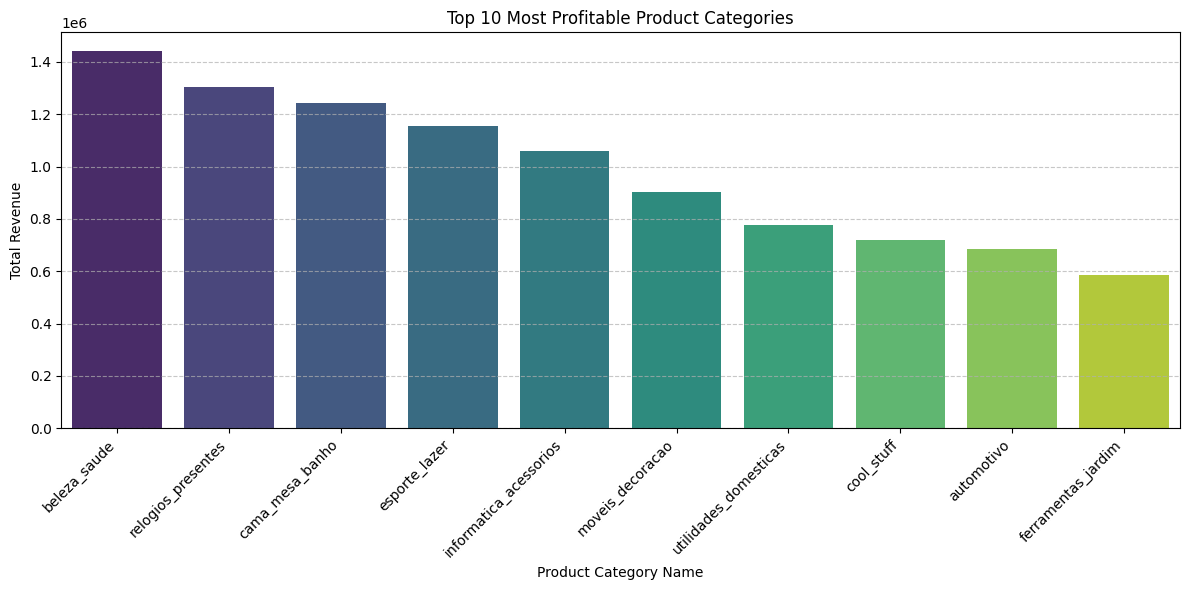

In [ ]:
# Calculate total revenue for each product category
product_category_revenue = master_df.groupby('product_category_name')\
                               .agg(total_product_revenue=('price', 'sum'),
                                    total_freight_value=('freight_value', 'sum'))\
                               .reset_index()

product_category_revenue['total_revenue'] = product_category_revenue['total_product_revenue'] + product_category_revenue['total_freight_value']

# Sort by total revenue and get the top 10
top_10_profitable_categories = product_category_revenue.sort_values(by='total_revenue', ascending=False).head(10)

print("Top 10 Most Profitable Product Categories:")
display(top_10_profitable_categories)

plt.figure(figsize=(12, 6))
sns.barplot(x='product_category_name', y='total_revenue', data=top_10_profitable_categories, palette='viridis', hue='product_category_name', legend=False)
plt.title('Top 10 Most Profitable Product Categories')
plt.xlabel('Product Category Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **Dashboard 2: Logistics & Customer Satisfaction**

### **Map Visualization: Average Shipping Cost and Average Delivery Delay per State**

In [ ]:
import folium
from folium.plugins import MarkerCluster

# Calculate average freight value and average delivery delay per state
state_logistics_metrics = master_df.groupby('customer_state').agg(
    avg_freight_value=('freight_value', 'mean'),
    avg_delivery_delay_days=('delivery_delay_days', 'mean')
).reset_index()

# Merge with geolocation data to get coordinates for each state
# We'll use the mean latitude and longitude for each state
state_geolocation = geolocation_df.groupby('geolocation_state').agg(
    mean_lat=('geolocation_lat', 'mean'),
    mean_lon=('geolocation_lng', 'mean')
).reset_index()

state_logistics_geospatial = pd.merge(
    state_logistics_metrics,
    state_geolocation,
    left_on='customer_state',
    right_on='geolocation_state',
    how='inner'
)

# Create a base map centered around Brazil
brazil_center_lat = -14.235
brazil_center_lon = -51.925
m2 = folium.Map(location=[brazil_center_lat, brazil_center_lon], zoom_start=4)

# Add markers for each state, colored by average delay and sized by average freight
for idx, row in state_logistics_geospatial.iterrows():
    # Normalize delay and freight for coloring and sizing
    # Using a simple linear normalization for visualization purposes
    normalized_delay = (row['avg_delivery_delay_days'] - state_logistics_geospatial['avg_delivery_delay_days'].min()) / \
                       (state_logistics_geospatial['avg_delivery_delay_days'].max() - state_logistics_geospatial['avg_delivery_delay_days'].min())

    normalized_freight = (row['avg_freight_value'] - state_logistics_geospatial['avg_freight_value'].min()) / \
                         (state_logistics_geospatial['avg_freight_value'].max() - state_logistics_geospatial['avg_freight_value'].min())

    # Choose color based on delay (e.g., green for low delay, red for high delay)
    color = plt.cm.RdYlGn(1 - normalized_delay) # Invert for red=high delay, green=low delay
    color_hex = '#%02x%02x%02x' % (int(color[0]*255), int(color[1]*255), int(color[2]*255))

    # Choose radius based on freight value
    radius = 5 + (normalized_freight * 15) # Base radius + scaled freight

    folium.CircleMarker(
        location=[row['mean_lat'], row['mean_lon']],
        radius=radius,
        color=color_hex,
        fill=True,
        fill_color=color_hex,
        fill_opacity=0.7,
        tooltip=f"{row['customer_state']}: Avg Delay: {row['avg_delivery_delay_days']:.2f} days, Avg Freight: R$ {row['avg_freight_value']:.2f}"
    ).add_to(m2)

print("Generating interactive map for logistics metrics...")
display(m2)

Generating interactive map for logistics metrics...


### **Relationship between Shipping Cost, Delivery Time, and Review Score**

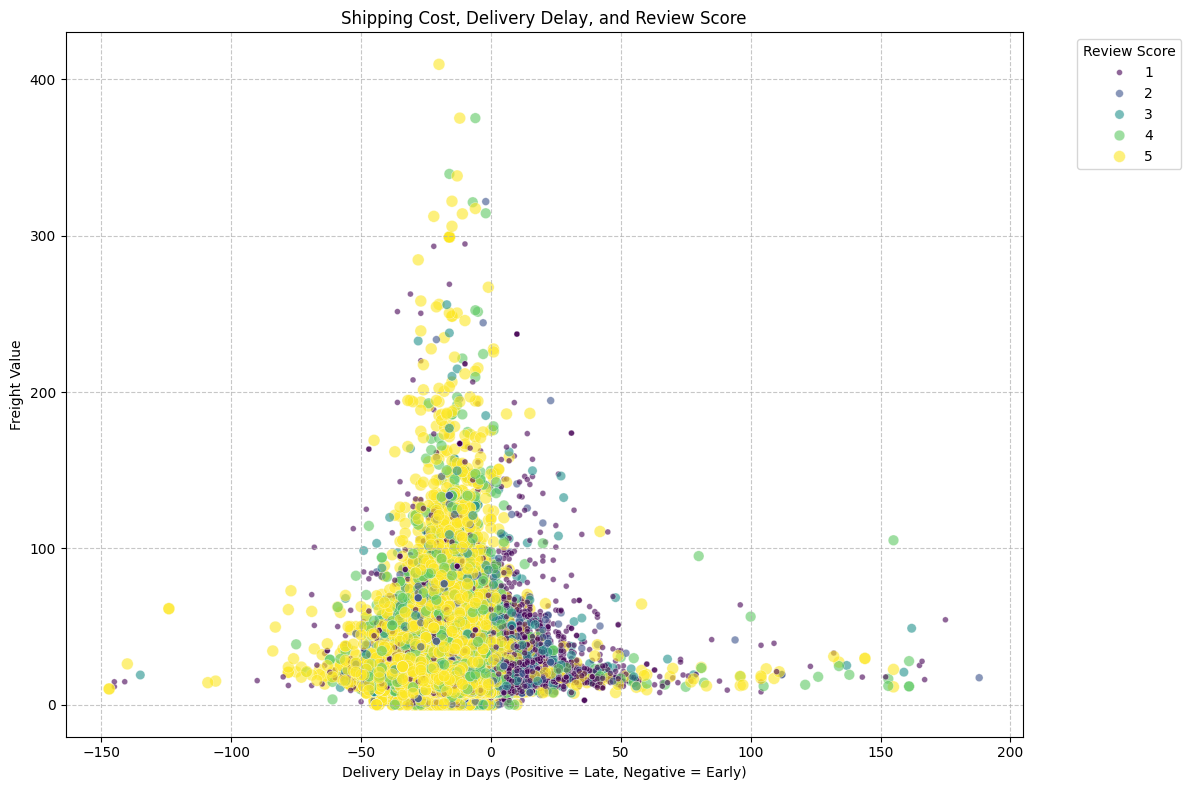

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure merged_df_for_correlation is available from previous steps
# If not, recreate it:
merged_df_for_correlation = pd.merge(master_df, reviews_df, on='order_id', how='inner')

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=merged_df_for_correlation,
    x='delivery_delay_days',
    y='freight_value',
    hue='review_score',
    size='review_score',
    palette='viridis',
    alpha=0.6
)
plt.title('Shipping Cost, Delivery Delay, and Review Score')
plt.xlabel('Delivery Delay in Days (Positive = Late, Negative = Early)')
plt.ylabel('Freight Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Review Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## **Data Storytelling & Đề xuất (Actionable Insights):**

## **6. Product & Sales Performance Analysis**

### **6.1 Top Categories by Revenue**

Top 10 Product Categories by Revenue (English Names):


,product_category_name_english,total_revenue
43,health_beauty,1258681.34
73,watches_gifts,1205005.68
7,bed_bath_table,1036988.68
67,sports_leisure,988048.97
15,computers_accessories,911954.32
39,furniture_decor,729762.49
20,cool_stuff,635290.85
49,housewares,632248.66
5,auto,592720.11
42,garden_tools,485256.46


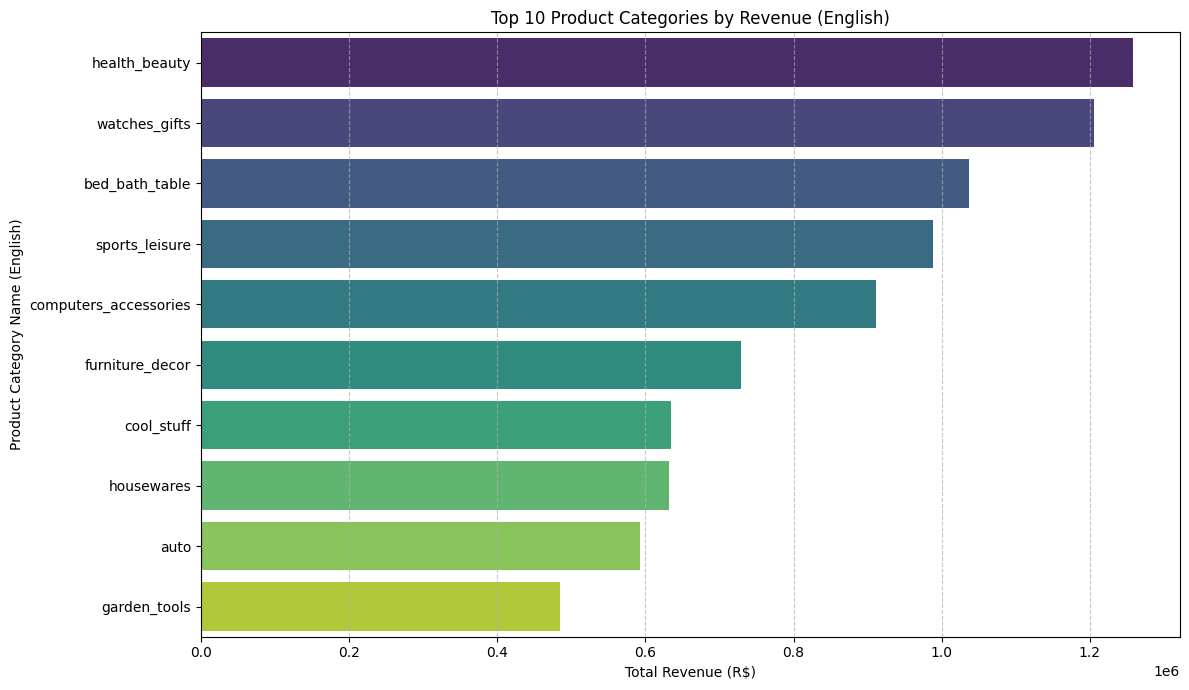

In [ ]:
# Load the product category name translation DataFrame
product_category_translation_df = dataframes['product_category_name_translation']

# Merge master_df with the translation DataFrame
# We need to do a left merge to keep all orders from master_df
# and translate product category names where possible.
merged_df_with_english_categories = pd.merge(
    master_df,
    product_category_translation_df,
    on='product_category_name',
    how='left'
)

# Fill any untranslated categories with their original Portuguese name or 'unknown'
merged_df_with_english_categories['product_category_name_english'] = \
    merged_df_with_english_categories['product_category_name_english'].fillna(merged_df_with_english_categories['product_category_name'])

# Calculate total revenue per English product category
category_revenue = merged_df_with_english_categories.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum') # Assuming price already includes freight for this analysis, or add freight here if needed
).reset_index()

# Sort by total revenue and get the top 10
top_10_categories_by_revenue = category_revenue.sort_values(by='total_revenue', ascending=False).head(10)

print("Top 10 Product Categories by Revenue (English Names):")
display(top_10_categories_by_revenue)

# Visualize the top 10 categories
plt.figure(figsize=(12, 7))
sns.barplot(x='total_revenue', y='product_category_name_english', data=top_10_categories_by_revenue, palette='viridis', hue='product_category_name_english', legend=False)
plt.title('Top 10 Product Categories by Revenue (English)')
plt.xlabel('Total Revenue (R$)')
plt.ylabel('Product Category Name (English)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **6.2 Price Distribution**

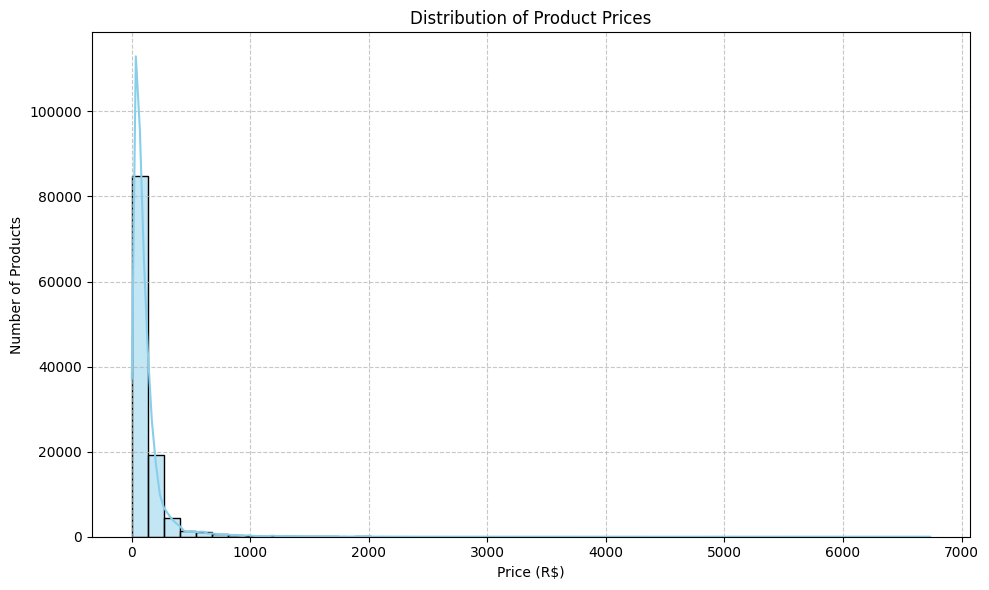

Descriptive statistics for product prices:


,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


In [ ]:
# Plotting the distribution of product prices
plt.figure(figsize=(10, 6))
sns.histplot(master_df['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Product Prices')
plt.xlabel('Price (R$)')
plt.ylabel('Number of Products')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Descriptive statistics for product prices:")
display(master_df['price'].describe())

### **Unresolved Questions/Tasks: Deeper Analysis of Delivery Delay Rate per State**

Delivery Performance by State (sorted by Late Delivery Rate):


,customer_state,total_deliveries,late_deliveries,late_delivery_rate
1,AL,444,89,20.045045
9,MA,824,144,17.475728
24,SE,385,61,15.844156
5,CE,1478,195,13.193505
16,PI,542,71,13.099631
4,BA,3799,438,11.529350
18,RJ,14579,1646,11.290212
13,PA,1080,119,11.018519
7,ES,2256,239,10.593972
14,PB,602,63,10.465116


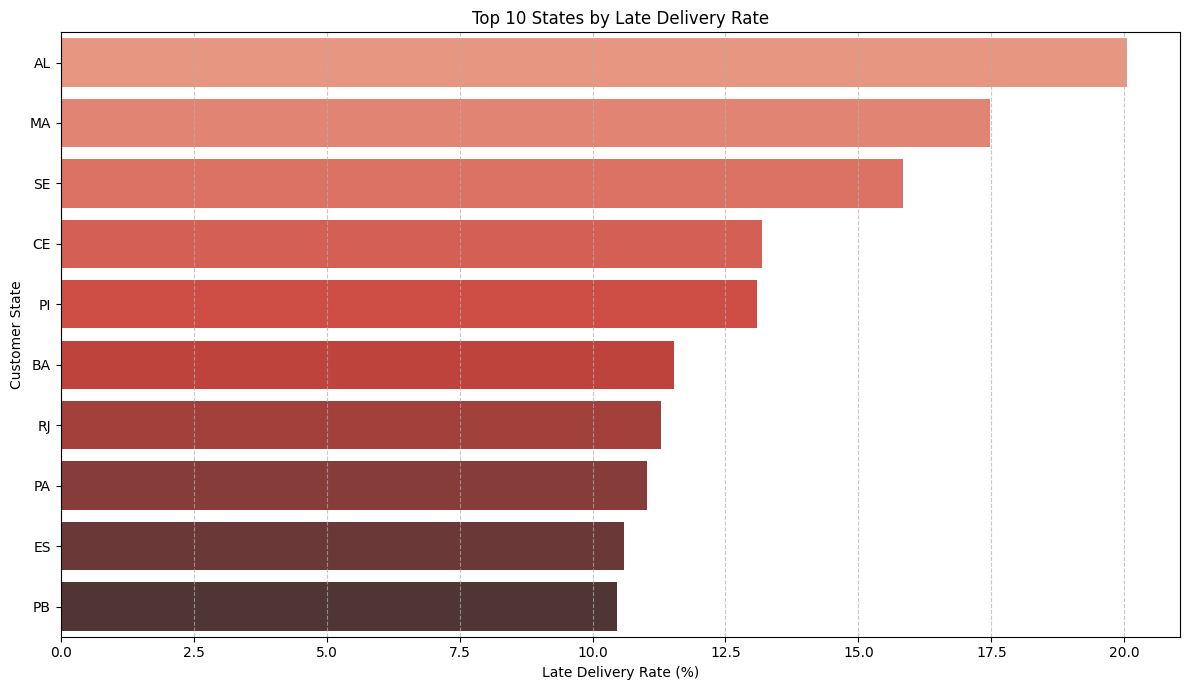

In [ ]:
# Calculate total deliveries per state
total_deliveries_per_state = master_df.groupby('customer_state').size().reset_index(name='total_deliveries')

# Calculate late deliveries per state
# A delivery is considered 'late' if delivery_delay_days > 0
late_deliveries_per_state = master_df[master_df['delivery_delay_days'] > 0] \
    .groupby('customer_state').size().reset_index(name='late_deliveries')

# Merge the two dataframes
delivery_performance = pd.merge(total_deliveries_per_state, late_deliveries_per_state, on='customer_state', how='left')

# Fill NaN values in 'late_deliveries' with 0 (for states with no late deliveries)
delivery_performance['late_deliveries'] = delivery_performance['late_deliveries'].fillna(0).astype(int)

# Calculate the late delivery rate
delivery_performance['late_delivery_rate'] = (delivery_performance['late_deliveries'] / delivery_performance['total_deliveries']) * 100

# Sort by late_delivery_rate in descending order
delivery_performance_sorted = delivery_performance.sort_values(by='late_delivery_rate', ascending=False)

print("Delivery Performance by State (sorted by Late Delivery Rate):")
display(delivery_performance_sorted.head(10))

# Visualize the top 10 states by late delivery rate
plt.figure(figsize=(12, 7))
sns.barplot(x='late_delivery_rate', y='customer_state', data=delivery_performance_sorted.head(10), palette='Reds_d', hue='customer_state', legend=False)
plt.title('Top 10 States by Late Delivery Rate')
plt.xlabel('Late Delivery Rate (%)')
plt.ylabel('Customer State')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Insight 1: Phí vận chuyển và thời gian giao hàng tới các bang phía Bắc (như Roraima, Amazonas) quá cao, dẫn đến review 1 sao tập trung ở đây.**

**Đề xuất 1: Olist nên tìm kiếm hoặc trợ giá cho đối tác vận chuyển địa phương tại miền Bắc, hoặc thiết lập các kho trung chuyển (hub) gần khu vực này hơn.**

### **Insight 2: Hình thức thanh toán bằng thẻ tín dụng có giá trị đơn hàng (AOV) cao hơn hẳn so với trả bằng Boleto.**

**Đề xuất 2: Có các chiến dịch khuyến mãi, giảm giá phí ship cho khách hàng thanh toán bằng thẻ tín dụng để kích thích mua sắm các sản phẩm giá trị cao.**

### **Chiến lược Marketing dựa trên Insight về thẻ tín dụng:**

**Mục tiêu:** Tăng cường việc sử dụng thẻ tín dụng, đặc biệt cho các giao dịch giá trị cao, để nâng cao tổng doanh thu và AOV.

**Các hành động cụ thể:**

1.  **Chương trình khuyến mãi giảm giá/hoàn tiền độc quyền cho thanh toán thẻ tín dụng:**
    *   **Giảm giá trực tiếp:** Ví dụ: "Giảm X% khi thanh toán bằng thẻ tín dụng cho đơn hàng trên Y R$" hoặc "Hoàn tiền Z% vào tài khoản tín dụng cho các giao dịch lớn."
    *   **Miễn phí vận chuyển:** Đối với các đơn hàng đủ điều kiện thanh toán bằng thẻ tín dụng có giá trị cao, miễn phí vận chuyển hoặc giảm phí vận chuyển đáng kể.

2.  **Hợp tác với các ngân hàng/tổ chức phát hành thẻ tín dụng:**
    *   Thực hiện các chiến dịch đồng thương hiệu với các ngân hàng lớn ở Brazil để cung cấp ưu đãi đặc biệt cho chủ thẻ của họ khi mua sắm trên Olist.
    *   Tổ chức các sự kiện hoặc chương trình tích điểm thưởng cho khách hàng sử dụng thẻ tín dụng của đối tác.

3.  **Tối ưu hóa trải nghiệm người dùng (UX) cho thanh toán thẻ tín dụng:**
    *   Đảm bảo quy trình thanh toán bằng thẻ tín dụng nhanh chóng, tiện lợi và an toàn.
    *   Lưu trữ thông tin thẻ (với sự đồng ý của khách hàng và đảm bảo bảo mật) để mua hàng nhanh hơn trong tương lai.

4.  **Truyền thông tập trung vào lợi ích của thẻ tín dụng:**
    *   Nhấn mạnh tính linh hoạt, tiện lợi, bảo mật và khả năng mua sắm các sản phẩm giá trị cao mà không cần thanh toán toàn bộ ngay lập tức.
    *   Sử dụng các kênh marketing như email, quảng cáo trên mạng xã hội, thông báo trong ứng dụng để giới thiệu các ưu đãi thẻ tín dụng.

5.  **Phân khúc khách hàng và ưu đãi cá nhân hóa:**
    *   Dựa trên RFM segmentation, nhắm mục tiêu các khách hàng VIP hoặc Loyal bằng các ưu đãi thẻ tín dụng cao cấp hơn.
    *   Khuyến khích 'Potential Churn' hoặc 'Other Customers' thử sử dụng thẻ tín dụng với các ưu đãi hấp dẫn để giữ chân họ và tăng giá trị đơn hàng.

**KPIs để đo lường thành công:**

*   Tỷ lệ phần trăm đơn hàng thanh toán bằng thẻ tín dụng.
*   Tỷ lệ AOV của các đơn hàng thanh toán bằng thẻ tín dụng so với các phương thức khác.
*   Tỷ lệ chuyển đổi của các chiến dịch khuyến mãi thẻ tín dụng.
*   Doanh thu tổng thể từ các đơn hàng thanh toán bằng thẻ tín dụng.

## Executive Summary: Key Metrics (KPIs)
Total Revenue: R$ 15,843,553.24
Total Orders: 98,666
Total Customers: 95,420
Average Order Value (AOV): R$ 160.58

## Executive Summary: Trend Analysis


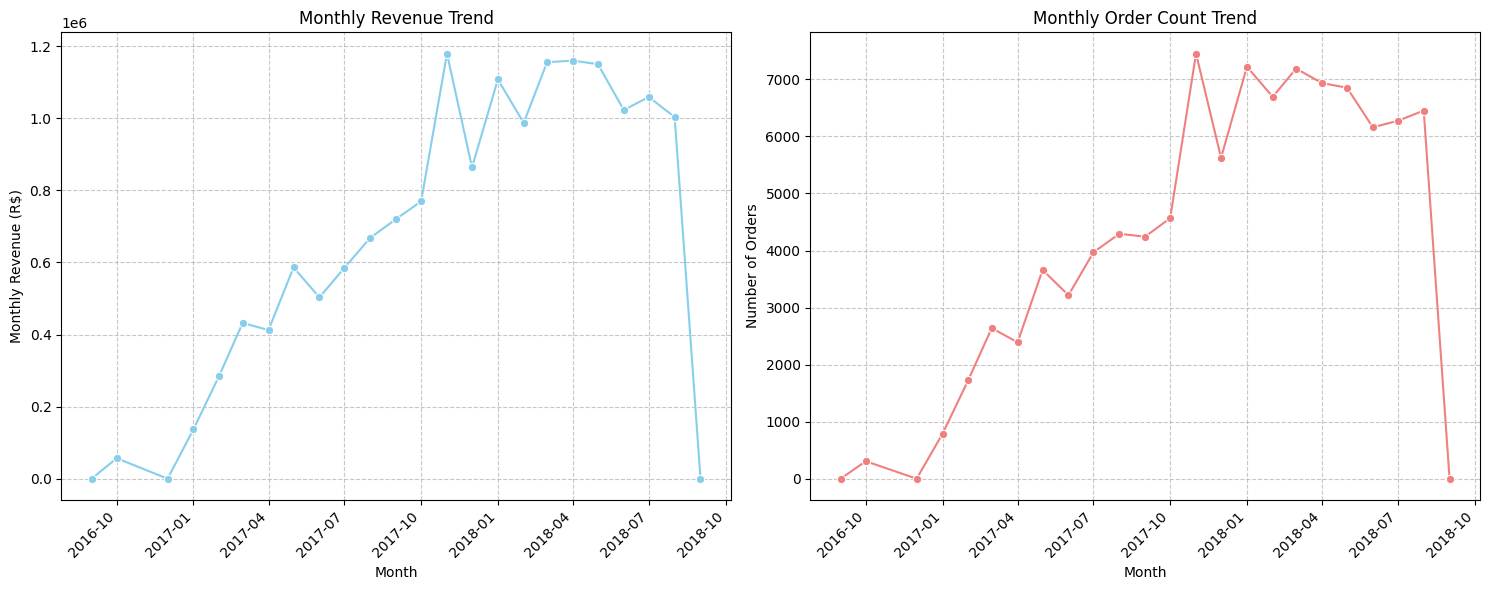


## Executive Summary: Payment Insights


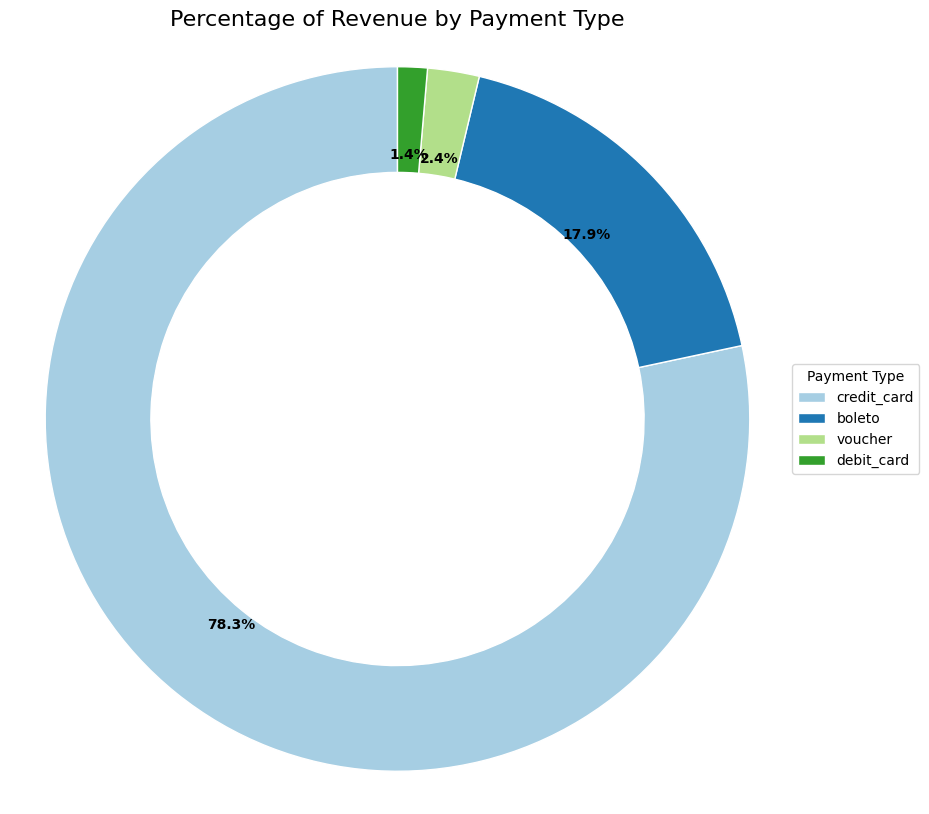

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Key Metrics (KPIs) ---
print("## Executive Summary: Key Metrics (KPIs)")

total_customers = master_df['customer_unique_id'].nunique()

print(f"Total Revenue: R$ {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Average Order Value (AOV): R$ {average_order_value:.2f}")

# --- 2. Trend Analysis: Monthly Revenue and Order Count ---
print("\n## Executive Summary: Trend Analysis")

# Prepare data for monthly order count
monthly_orders = master_df.set_index('order_purchase_timestamp').resample('ME')['order_id'].nunique().reset_index()
monthly_orders.rename(columns={'order_id': 'monthly_order_count'}, inplace=True)

# Merge with mom_revenue_df for plotting
# Ensure both dataframes have 'sale_month' as datetime for merging and plotting
mom_revenue_df['sale_month'] = pd.to_datetime(mom_revenue_df['sale_month'])
monthly_orders['order_purchase_timestamp'] = monthly_orders['order_purchase_timestamp'].dt.to_period('M')
mom_revenue_df['sale_month_period'] = mom_revenue_df['sale_month'].dt.to_period('M')

trend_df = pd.merge(mom_revenue_df, monthly_orders,
                    left_on='sale_month_period', right_on='order_purchase_timestamp',
                    how='left')
trend_df.rename(columns={'order_purchase_timestamp': 'month'}, inplace=True)
trend_df['month'] = trend_df['month'].dt.to_timestamp() # Convert back to timestamp for plotting

# Plotting Monthly Revenue and Order Count
plt.figure(figsize=(15, 6))

# Plot Monthly Revenue
plt.subplot(1, 2, 1)
sns.lineplot(x='month', y='monthly_revenue', data=trend_df, marker='o', color='skyblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Monthly Revenue (R$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

# Plot Monthly Order Count
plt.subplot(1, 2, 2)
sns.lineplot(x='month', y='monthly_order_count', data=trend_df, marker='o', color='lightcoral')
plt.title('Monthly Order Count Trend')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# --- 3. Payment Insights: Revenue Percentage by Payment Type (Donut Chart) ---
print("\n## Executive Summary: Payment Insights")

# Calculate percentage of total_payment_value for each payment type
payment_analysis_df['percentage'] = (payment_analysis_df['total_payment_value'] / payment_analysis_df['total_payment_value'].sum()) * 100

# Filter out payment types with 0% contribution to avoid clutter
filtered_payment_df = payment_analysis_df[payment_analysis_df['percentage'] > 0].copy()

# Create the donut chart
fig1, ax1 = plt.subplots(figsize=(10, 10)) # Increased figsize for better visibility
wedges, texts, autotexts = ax1.pie(filtered_payment_df['percentage'],
                                   autopct='%1.1f%%',
                                   startangle=90,
                                   pctdistance=0.75, # Adjusted distance of percentage labels
                                   colors=sns.color_palette('Paired', len(filtered_payment_df)), # Changed palette for better distinction
                                   wedgeprops=dict(width=0.3, edgecolor='w')) # Added wedgeprops for donut appearance and border

# Draw a white circle in the middle to create a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig1.gca().add_artist(centre_circle)

# Add custom legend outside the chart
ax1.legend(wedges, filtered_payment_df['payment_type'],
           title="Payment Type",
           loc="center left",
           bbox_to_anchor=(1, 0, 0.5, 1))

# Set font size and weight for percentages for better readability
plt.setp(autotexts, size=10, weight="bold", color='black')

ax1.set_title('Percentage of Revenue by Payment Type', fontsize=16) # Increased title font size
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

### **Nhận xét:**
**1. Xu hướng doanh thu hàng tháng:**

Xu hướng doanh thu hàng tháng cho thấy một mô hình tăng trưởng rõ ràng bắt đầu từ cuối năm 2016 và tăng tốc trong suốt năm 2017. Doanh thu đạt đỉnh điểm vào khoảng cuối năm 2017 đến đầu năm 2018, trước khi giảm dần vào cuối giai đoạn dữ liệu có sẵn vào giữa năm 2018. Điều này cho thấy một giai đoạn mở rộng mạnh mẽ, tiếp theo là sự chậm lại tiềm tàng hoặc bộ dữ liệu kết thúc trước khi chu kỳ hoàn chỉnh.

**2. Xu hướng số lượng đơn hàng hàng tháng:**

Tương tự như xu hướng doanh thu, số lượng đơn hàng hàng tháng cũng cho thấy sự tăng trưởng đáng kể trong suốt năm 2017 và đầu năm 2018, đạt mức cao nhất trong giai đoạn này. Số lượng đơn hàng sau đó dường như giảm nhẹ vào giữa năm 2018. Xu hướng số lượng đơn hàng phần lớn phản ánh xu hướng doanh thu, cho thấy sự tăng trưởng doanh thu được thúc đẩy bởi sự gia tăng số lượng giao dịch chứ không chỉ đơn thuần là do giá trị đơn hàng trung bình cao hơn.

**3. Tỷ lệ doanh thu theo loại hình thanh toán:**

Biểu đồ hình bánh vòng minh họa rõ ràng sự thống trị của phương thức thanh toán 'thẻ tín dụng', chiếm phần lớn (78,3%) tổng doanh thu. 'Boleto' là loại hình thanh toán quan trọng thứ hai, đóng góp 17,9% doanh thu. 'Phiếu quà tặng' và 'thẻ ghi nợ' chiếm tỷ lệ nhỏ hơn, lần lượt là 2,4% và 1,4%, trong khi 'không xác định' chiếm tỷ lệ không đáng kể. Điều này nhấn mạnh tầm quan trọng của các giao dịch bằng thẻ tín dụng đối với việc tạo doanh thu của Olist.